# Relatório Técnico: Pipeline MLOps para Previsão de Geração Eólica

Autor: Wanderson Ferreira
</div>
<left><img src="https://ne9.com.br/wp-content/uploads/2024/08/Parque-Eolico-Morro-de-Cruzeiro-da-Statkraft-Brasil-Foto-Divulgacao.webp"width="1000", height="680"/> <left> </div>
<p><left>(Parque Eólico Morro de Cruzeiro da da Statkraft Brasil, localizado em Brotas de Macaúbas, na Bahia. Foto Divulgação)</left></p>

***

---

### **Status Atual do Sistema MLOps:**

* **Extração & Contratos:** OK (Open-Meteo + ONS via Pandera)
* **Orquestração Executada:** OK (Prefect 3 rodando em Python 3.14)
* **Engenharia de Features:** OK (Transformador independente do orquestrador que deriva features físicas e sazonais relevantes)
* **Data Lake (RustFS / S3 Compatible):** OK (Migração concluída de MinIO para RustFS de alta performance sob licença Apache 2.0. Infraestrutura S3 local configurada via KinD/Helm e conectada nativamente ao pipeline Python, preservando os mesmos *endpoints* e integrando-se via Pydantic Settings).
* **Datasets Gerados na Camada Ouro (Gold):**
* `s3://energy-lake/gold/dataset_treino_2025_01.parquet` (744 linhas - baseline inicial)
* `s3://energy-lake/gold/dataset_renewable_energy_2024_1_2025_12.parquet` (17.544 linhas)
* `s3://energy-lake/gold/train_wind_energy_2024_01_expanding_up_to_2026_08.parquet` (23.373 linhas - *Sweet Spot* de Treino)
* `s3://energy-lake/gold/oot_test_wind_energy_2026_08.parquet` (744 linhas - Dados de Validação)

* **Treinamento, Ensemble & Rastreamento (MLflow):** Evolução para `StackingRegressor` [LGBM, XGBoost, RF: 0.183, 0.6599, 0.1443] -> Regressão Linear, com hiperparâmetros otimizados via Optuna. Validado com OOT MAE: `829.16 MW`, nMAE: `7.03%`, $R^2$: `0.8462`, serialização blindada multilib, Model Registry ativo em `ensemble_lgb_xgb_rf_bahia` com alias `champion`.
* **Explicabilidade de Modelo (SHAP):** Integrada. Pipelines de auditoria gerando artefatos globais e locais, salvos diretamente no RustFS/MLflow. Validação temporal estrita utilizando janelas de OOT com meses completos fechados (~744 amostras), garantindo densidade estatística ideal nos gráficos Summary, Dependence e Waterfall.
* **Quality Gate de Modelos:** Operacional. Sistema automatizado de avaliação **Champion vs. Challenger** fundamentado na *Navalha de Ockham* (Princípio da Parcimônia):
* **Acurácia:** Qualquer modelo *Challenger* que reduza o erro (MAE) em relação ao *Champion* atual é promovido automaticamente.
* **Simplificação Arquitetural:** Modelos com menor número de *features* são aprovados mesmo se apresentarem uma variação discreta no erro, desde que mantidos dentro da margem de tolerância de **$+0.05\%$ nMAE**.
* **Governança & Rastreabilidade:** Modelos rejeitados recebem a tag `REJECTED` no MLflow Model Registry acompanhados da justificativa técnica detalhada.


* **Model Serving & Kubernetes Infra:** OK. Modelo `@champion` operacionalizado via API FastAPI assíncrona focada em lotes (`/predict/batch`). A plataforma foi **100% conteinerizada** e implantada via Kubernetes (KinD/Helm) com Probes de *Readiness/Liveness* e suporte a **Hot-Reload In-Memory** via notificação HTTP.
* **Dashboard Interativo (UI) & Operações:** OK. Interface front-end desenvolvida em Streamlit atuando como cliente da API.
* Explicabilidade (XAI) 100% acoplada exibindo as decomposições matemáticas interativas (SHAP Summary e Waterfall Plots) processadas no backend.
* **Tradução para Visão de Negócios:** Inclusão nativa de métricas executivas, convertendo o erro normalizado em **Acurácia de Previsão Global** (ex: $92.97\%$ de precisão no modelo vigente).
* Ingestão contínua em tempo real da previsão climática das próximas 24h consumida diretamente da API Open-Meteo.
* Painel lateral de rastreamento operacional exibindo latência real da API Kubernetes e versão atualizada da *tag* `@champion` no Model Registry.


* **Camada de Testes de Software & MLOps:** OK. Suíte completa com 20 testes isolados, orquestrada via **Tox** em ambiente virtual efêmero (CI/CD ready).
* **Contratos (Schemas):** Validação estrita de DataFrames via Pandera e payloads HTTP via Pydantic.
* **Unidade & Features:** Verificação matemática (Seno/Cosseno, Razões físicas) e de junção temporal correta (`merge_asof`).
* **Integração (API):** Mocks do servidor MLflow via Pytest-Mock garantindo estabilidade do Lifespan da FastAPI.
* **Heurísticas do Modelo:** Invariância temporal, checagem de monotonicidade e teste de calmaria (vento zero = potência marginal).



---

## 1. Introdução ao Problema

A transição energética global exige uma integração eficiente de fontes renováveis nas redes de distribuição. Diferente de usinas termelétricas, a geração de energia eólica é altamente estocástica, dependendo exclusivamente das condições meteorológicas (velocidade e direção do vento, densidade do ar).

O desafio técnico deste projeto é desenvolver um sistema preditivo de **Machine Learning em produção (MLOps)** capaz de estimar a geração de energia eólica no Estado da Bahia (maior polo gerador do país). O objetivo não é apenas treinar um modelo, mas construir um pipeline resiliente e automatizado que orquestre a ingestão de dados meteorológicos (Open-Meteo) e de geração real (ONS - Operador Nacional do Sistema Elétrico), garantindo a qualidade e a integridade dos dados através de contratos rígidos antes de qualquer etapa de treinamento ou inferência.

---

## 2. Dicionário de Dados

A arquitetura de dados consolida variáveis de duas fontes distintas, alinhadas em uma granularidade temporal **horária** (UTC).

### 2.1. Variáveis Meteorológicas (Features - `Open-Meteo API`)

Extraídas para a localização do Complexo Lagoa dos Ventos (Piauí).

* **`date`** (`datetime64[ns, UTC]`): Timestamp horário da medição climática.
* **`temperature_2m`** (`float64`): Temperatura do ar a 2 metros do solo (°C). Impacta diretamente a densidade do ar.
* **`wind_speed_100m`** (`float64`): Velocidade do vento a 100 metros de altura (km/h). Reflete a altura do rotor das turbinas eólicas, sendo a principal variável para o cálculo de potência.
* **`wind_direction_100m`** (`float64`): Direção do vento a 100 metros (graus, 0-360°). Essencial para avaliar o alinhamento com a topografia e disposição do parque eólico.

### 2.2. Variável de Geração de Energia (Target - `ONS Open Data`)

Extraídas do datalake público do ONS (formato Parquet), filtradas para o subsistema Nordeste (`NE`) e tipo de usina Eoliétrica.

* **`date`** (`datetime64[ns, UTC]`): Timestamp horário convertido do fuso de Brasília (America/Sao_Paulo) para UTC, permitindo o *merge* temporal exato com os dados climáticos.
* **`wind_generation_mw`** (`float64`): Geração total horária agregada de energia eólica (Megawatts - MW).

---

## 3. Design da Solução e Arquitetura

## O repositório foi estruturado seguindo os padrões modernos de engenharia de software e MLOps. A gestão de dependências é feita via **Poetry** e o pacote principal é instalável localmente (`energy_mlops`).

```text
renewable-energy-mlops/
├── Dockerfile                         # Configuração da imagem do serviço FastAPI
├── Makefile                           # Automação (ports, stop-ports, test-opt, test-train)
├── pyproject.toml                     # Dependências (Poetry) e ferramentas de linting
├── poetry.lock                        # Lockfile de dependências exatas
├── tox.ini                            # Orquestrador de testes isolados para CI/CD
├── README.md                          # Documentação geral do repositório
├── lista_ordenada_de_comandos_bash.txt # Histórico de comandos e setup do ambiente
├── helm/                              # Infraestrutura Kubernetes (KinD)
│   ├── Chart.yaml             
│   ├── values.yaml            
│   └── templates/             
│       ├── api.yaml                   # Deploy e Service do Model Serving (FastAPI)
│       ├── rustfs.yaml                # Object Storage local (PVC + S3 MinIO compatible)
│       ├── mlflow.yaml                # Deployment do MLflow Tracking Server
│       └── postgres.yaml              # Banco de dados de metadados do MLflow (PVC)
├── notebooks/                 
│   └── renewable-energy-mlops.ipynb   # Documentação e relatório técnico central
├── src/
│   └── energy_mlops/          
│       ├── __init__.py
│       ├── config.py                  # Pydantic Settings (Conexões S3, MLflow, etc.)
│       ├── app/
│       │   └── app.py                 # Interface / Dashboard de monitoramento
│       ├── data/              
│       │   ├── build_features.py      # Engenharia de atributos e merge temporal (pd.merge_asof)
│       │   ├── extract_energy.py      # Extração de dados de geração eólica
│       │   ├── extract_weather.py     # Extração de dados meteorológicos
│       │   ├── schema.py              # Validação de schema de entrada/saída (Pandera)
│       │   └── schema_data.py         # Schemas de dados processados
│       ├── models/            
│       │   ├── interfaces.py          # Contratos de interface (ModelTrainer, ModelOptimizer)
│       │   ├── optimize_stacking.py   # Otimização de hiperparâmetros com Optuna
│       │   ├── train_stacking.py      # Algoritmo principal (Stacking Ensemble LGBM+XGB+RF)
│       │   ├── train_examples.py      # Exemplos de referência e Mocks para testes (Dummy, Ridge, PyTorch)
│       │   └── train.py               # Scripts auxiliares de treino
│       ├── pipelines/         
│       │   ├── backfill_flow.py       # Pipeline Prefect de carga histórica de dados
│       │   ├── data_ingestion_flow.py # Pipeline Prefect de ingestão diária de dados
│       │   ├── training_flow.py       # Pipeline Prefect de Treinamento Contínuo (CT) agnóstico
│       │   └── utils.py               # Utilitários de Io e persistência no Data Lake
│       └── service/                   # Camada de Serviço (Model Serving)
│           ├── main.py                # Endpoint assíncrono FastAPI (/predict/batch e /reload-model)
│           └── schema.py              # Contratos Pydantic para validação das requisições HTTP
└── tests/                     
    ├── conftest.py                    # Fixtures globais do pytest
    ├── test_config.py                 # Testes de variáveis de ambiente e Pydantic Settings
    ├── data/
    │   ├── test_schema.py             # Testes de validação de schemas Pandera
    │   └── test_build_features.py     # Testes de engenharia de features (merge temporal)
    ├── models/
    │   └── test_heuristics.py         # Testes comportamentais e heurísticos do modelo
    └── service/
        ├── test_schema.py             # Testes de validação de payload Pydantic
        └── test_main.py               # Testes de integração das rotas HTTP da FastAPI

```



## Diagrama arquitetural com o host, o gerenciamento de rede e o cluster Kubernetes com os Volumes Persistentes (PVCs):

```text

 [ Streamlit Dashboard ]      ┌──────────────────────────────────────────────────────────────────────────────┐
 [ (app.py via Poetry) ]      │                                MÁQUINA HOST (Alienware-16)                   │
           │                  │                                                                              │
           │                  │      ┌───────────────────────┐             ┌─────────────────────────┐       │
           └─────────────────▶│      │ GERENCIAMENTO DE REDE │             │ AMBIENTE LOCAL (Poetry) │       │
      POST /predict/batch     │      │                       │             │                         │       │
    (http://localhost:8000)   │      │ ▹ make ports          │             │ ▹ tox (Test Suite)      │       │
                              │      │   (port-forward 8000) │             │ ▹ Orquestração (Prefect)│       │
                              │      └───────────┬───────────┘             │ ▹ Model Training        │       │
                              │                  │                         │ ▹ Streamlit UI (:8501)  │       │
                              │                  │                         └───────────┬─────────────┘       │
                              └──────────────────┼─────────────────────────────────────┼─────────────────────┘
                                                 │ Túnel K8s                           │ Conexões (9000, 5000)
                                                 ▼                                     ▼
┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                   KUBERNETES CLUSTER (KinD - Docker Container)                                │
│                                   NODE: energy-mlops-control-plane                                            │
│                                                                                                               │
│             ┌─────────────────────────────┐      ┌──────────────────────────┐      ┌───────────────────────┐  │
│             │ POD: api-deployment-xxx     │      │ POD: mlflow--xxx         │      │ POD: postgres-xxx     │  │
│             │ (FastAPI Model Serving)     │      │ (Tracking Server)        │      │ (Database do MLflow)  │  │
│             │                             │      │                          │      │                       │  │
│             │ ┌─────────────────────────┐ │      │ ┌──────────────────────┐ │      │ ┌───────────────────┐ │  │
│             │ │ CONTAINER: energy-api   │─┼─────▶│ │ CONTAINER: mlflow    │─┼─────▶│ │ CONTAINER: post...│ │  │
│             │ │ ▹ :8000 (REST API)      │ │      │ │ ▹ :5000 (UI/API)     │ │      │ │ ▹ :5432 (TCP)     │ │  │
│             │ └─────────┬───────────────┘ │      │ └──────────────────────┘ │      │ └─────────┬─────────┘ │  │
│             └───────────┼─────────────────┘      └────────────┬─────────────┘      └───────────┼───────────┘  │
│                         │                                     │                                │  (PVC)       │
│                         │ Lê modelo @champion                 │ Salva Artefatos                ▼              │
│                         ▼                                     │                      [ postgres-pvc:2Gi ]     │
│             ┌─────────────────────────────┐                   │                                               │
│             │ POD: minio-xxx              │◀──────────────────┘                                               │
│             │ (Data Lake / Model Registry)│                                                                   │
│             │                             │                                                                   │
│             │ ┌─────────────────────────┐ │  (PVC)                                                            │
│             │ │ CONTAINER: minio        │─┼──────────▶ [ minio-pvc:5Gi ]                                      │
│             │ │ ▹ :9000 (S3 API)        │ │            (Garante retenção do Data Lake e Modelos)              │
│             │ └─────────────────────────┘ │                                                                   │
│             └─────────────────────────────┘                                                                   │
└───────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

```



---

## P1 - Pipeline (Flow) de Ingestão

Aqui foi desenvolvemos uma espécie de "Feature Store inicial" para começarmos a treinar a nossa Rede Neural/Modelo de ML onde considera-se:

1. Um extrator de Features (Clima - X)

2. Um extrator de Target (Energia - Y)

3. Ambos com seus respectivos contrato de dados do pantera que intercepta dados anômalos (Validação de Tipos, Outliers e Mudanças de Fonte).

Os extratores são unidos através do orquestrador Prefect apartir dos seguintes decorators:

* **`@task`**: Uma unidade de trabalho (ex: extrair clima, extrair energia, juntar os dois).
* **`@flow`**: O pipeline principal que coordena as tasks.

*Nota de Engenharia:* Os arquivos `extract_weather.py` e `extract_energy.py` não são alterados. Ambos foram importá-los e "envelopá-dos" em tasks do Prefect. Isso mantém a separação de responsabilidades (código de dados puro isolado do código do orquestrador: src/energy_mlops/pipelines/`data_ingestion_flow.py`).

## P1.1. Script de Análise Exploratória de Dados (EDA)  - Período 2023 a 2025

Após os testes iniciais em que o orquestrador gerenciou com sucesso a extração dos dados de janeiro de 2025: $744$ registros exatos para janeiro ($31\text{ dias} \times 24\text{ horas} = 744$). O join temporal alinhou velocidade, direção do vento, temperatura e geração em MW hora a hora sem nenhuma lacuna.

<img src="extract_test.png" width="1100">

Conforme se segue, prosseguiu-se com a realização de um Backfill Histórico para iterar sequencialmente sobre todos os meses de 2023 a 2025 (36 meses no total), consolidando o dataset em um único arquivo .parquet master (O script do backfill esta localizado em `src/energy_mlops/pipelines/backfill_flow.py`). Essa etapa permitiu realizar uma síntese estatística de um dataset consolidado de 3 anos de medições horárias contínuas (~26.304 registros).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# Carregar dataset completo
df = pd.read_parquet("../data/dataset_historico_2023_2025.parquet")

#  Estatísticas Descritivas
print("--- Visão Geral do Dataset ---")
print(f"Período: {df['date'].min()} até {df['date'].max()}")
print(f"Total de Horas Observadas: {len(df):,}")
print(f"Valores Ausentes:\n{df.isnull().sum()}\n")

print("--- Estatísticas Numéricas ---")
print(df[["wind_speed_100m", "temperature_2m", "wind_generation_mw"]].describe().T)

# Matriz de Correlação Linear
corr = df[["wind_speed_100m", "wind_direction_100m", "temperature_2m", "wind_generation_mw"]].corr()
print("\n--- Correlação com a Geração (Target) ---")
print(corr["wind_generation_mw"].sort_values(ascending=False))

#  Perfis Médios por Hora do Dia
df['hour'] = df['date'].dt.hour
hourly_profile = df.groupby('hour')[['wind_speed_100m', 'wind_generation_mw']].mean()
print("\n--- Horário de Pico de Vento x Geração Média ---")
print(hourly_profile.sort_values(by="wind_generation_mw", ascending=False).head(24))

--- Visão Geral do Dataset ---
Período: 2023-01-01 03:00:00 até 2026-01-01 02:00:00
Total de Horas Observadas: 26,304
Valores Ausentes:
date                   0
wind_speed_100m        0
wind_direction_100m    0
temperature_2m         0
wind_generation_mw     0
dtype: int64

--- Estatísticas Numéricas ---
                      count         mean          std     min          25%  \
wind_speed_100m     26304.0    23.696213     7.167144   0.360    19.160703   
temperature_2m      26304.0    20.475441     3.853555  12.100    17.600000   
wind_generation_mw  26304.0  4096.434799  2324.321783  53.819  2133.110000   

                            50%          75%           max  
wind_speed_100m       23.833182    28.460497     52.488441  
temperature_2m        19.799999    23.100000     33.750000  
wind_generation_mw  4151.848500  5713.510250  10373.281000  

--- Correlação com a Geração (Target) ---
wind_generation_mw     1.000000
wind_speed_100m        0.680618
wind_direction_100m   -0.00443

### P1.2. Resultados Estatísticos

Com a execução bem-sucedida do pipeline iterativo de *backfill* via Prefect (agora calibrado para o fuso horário correto e focado no estado líder em produção), consolidamos **26.304 registros horários** cobrindo o período de **01/01/2023 às 03:00 UTC** até **01/01/2026 às 02:00 UTC**.

### 1. Qualidade e Integridade do Dataset

*   **Valores Ausentes:** 0 (zerado em todas as colunas). O contrato de dados via Pandera garantiu a integridade da extração.
*   **Volumetria de Linhas:** 26.304 horas contínuas sem lacunas temporais.
*   **Schema de Saída:**
    *   `date` (`datetime64[ns, UTC]`)
    *   `wind_speed_100m` (`float64`)
    *   `wind_direction_100m` (`float64`)
    *   `temperature_2m` (`float64`)
    *   `wind_generation_mw` (`float64`)

---


### 2. Sumário Estatístico

| Métrica | Vento 100m (`km/h`) | Temperatura 2m (`°C`) | Geração Eólica BA (`MW`) |
| :--- | :--- | :--- | :--- |
| **Média** | `23,69` | `20,47` | `4.096,43` |
| **Desvio Padrão** | `7,16` | `3,85` | `2.324,32` |
| **Mínimo** | `0,36` | `12,10` | `53,81` |
| **Mediana (50%)** | `23,83` | `19,79` | `4.151,84` |
| **Máximo** | `52,48` | `33,75` | `10.373,28` |

---

### 3. Análise de Correlação Linear com o Target (`wind_generation_mw`)

A matriz de correlação de Pearson demonstra:

*   **`wind_speed_100m` ($+0.6806$):** Forte correlação positiva direta, consolidando-se como a *feature* primária do modelo.
*   **`temperature_2m` ($-0.6717$):** Forte correlação negativa. Este é um achado crucial: na região da Chapada Diamantina, o aumento da geração eólica está fortemente associado às quedas de temperatura, provavelmente devido ao ciclo de ventos noturnos/madrugada mais frios e densos.
*   **`wind_direction_100m` ($-0.0044$):** Correlação nula. Para o modelo agregado estadual, a direção do vento provou-se irrelevante em termos lineares.

---


In [20]:
# --- Engenharia de Features Temporais para Sazonalidade ---
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year_quarter"] = df["year"].astype(str) + "-Q" + df["quarter"].astype(str)

# Flag da "Safra dos Ventos" no Nordeste (Geralmente Agosto a Novembro)
df["safra_ventos"] = df["month"].isin([8, 9, 10, 11]).map({True: "Safra (Ago-Nov)", False: "Fora de Safra"})

# --- Agregações por Trimestre e Ano ---
pivot_generation = df.pivot_table(
    index="year", 
    columns="quarter", 
    values="wind_generation_mw", 
    aggfunc=["mean", "std"]
)
print("=== Geração Média (MW) por Ano e Trimestre ===")
print(pivot_generation.round(2))

=== Geração Média (MW) por Ano e Trimestre ===
            mean                                 std                    \
quarter        1        2        3        4        1        2        3   
year                                                                     
2023     3089.41  3521.81  3985.05  3388.39  1640.86  1680.42  1596.08   
2024     2457.38  4285.74  5258.58  4223.25  1810.16  1795.78  1831.16   
2025     3293.04  5108.14  5982.23  4511.11  2307.27  2377.21  2699.29   
2026     5091.75      NaN      NaN      NaN   465.46      NaN      NaN   

                  
quarter        4  
year              
2023     1835.37  
2024     2355.81  
2025     2891.52  
2026         NaN  


In [21]:
# --- Testes Estatísticos ---
print("\n" + "="*50)
print("=== RESULTADOS DOS TESTES ESTATÍSTICOS ===")

# A. Teste de Estacionariedade (ADF) na Geração
adf_result = adfuller(df["wind_generation_mw"].dropna(), result_object=True)
print(f"\n1. Teste de Estacionariedade (ADF) - Geração (MW):")
print(f"   - Estatística ADF: {adf_result[0]:.4f}")
print(f"   - p-valor: {adf_result[1]:.4e}")
print(f"   - Resultado: {'Série Estacionária (Rejeita H0)' if adf_result[1] < 0.05 else 'Não Estacionária'}")

# B. Teste Kruskal-Wallis (Sazonalidade entre Trimestres)
q1 = df[df["quarter"] == 1]["wind_generation_mw"]
q2 = df[df["quarter"] == 2]["wind_generation_mw"]
q3 = df[df["quarter"] == 3]["wind_generation_mw"]
q4 = df[df["quarter"] == 4]["wind_generation_mw"]
kw_stat, kw_p = stats.kruskal(q1, q2, q3, q4)
print(f"\n2. Teste Kruskal-Wallis (Diferença entre Trimestres Q1-Q4):")
print(f"   - Estatística H: {kw_stat:.2f}")
print(f"   - p-valor: {kw_p:.4e}")
print(f"   - Resultado: {'Diferença Sazonal Estatisticamente Significativa' if kw_p < 0.05 else 'Sem Diferença Significativa'}")

# C. Correlação de Spearman vs Pearson
pearson_corr = df["wind_speed_100m"].corr(df["wind_generation_mw"], method="pearson")
spearman_corr = df["wind_speed_100m"].corr(df["wind_generation_mw"], method="spearman")
print(f"\n3. Comparação de Correlações (Vento x Geração):")
print(f"   - Pearson (Linear): {pearson_corr:.4f}")
print(f"   - Spearman (Monótona/Não-linear): {spearman_corr:.4f}")


=== RESULTADOS DOS TESTES ESTATÍSTICOS ===

1. Teste de Estacionariedade (ADF) - Geração (MW):
   - Estatística ADF: -10.6483
   - p-valor: 4.7338e-19
   - Resultado: Série Estacionária (Rejeita H0)

2. Teste Kruskal-Wallis (Diferença entre Trimestres Q1-Q4):
   - Estatística H: 2800.11
   - p-valor: 0.0000e+00
   - Resultado: Diferença Sazonal Estatisticamente Significativa

3. Comparação de Correlações (Vento x Geração):
   - Pearson (Linear): 0.6806
   - Spearman (Monótona/Não-linear): 0.6937


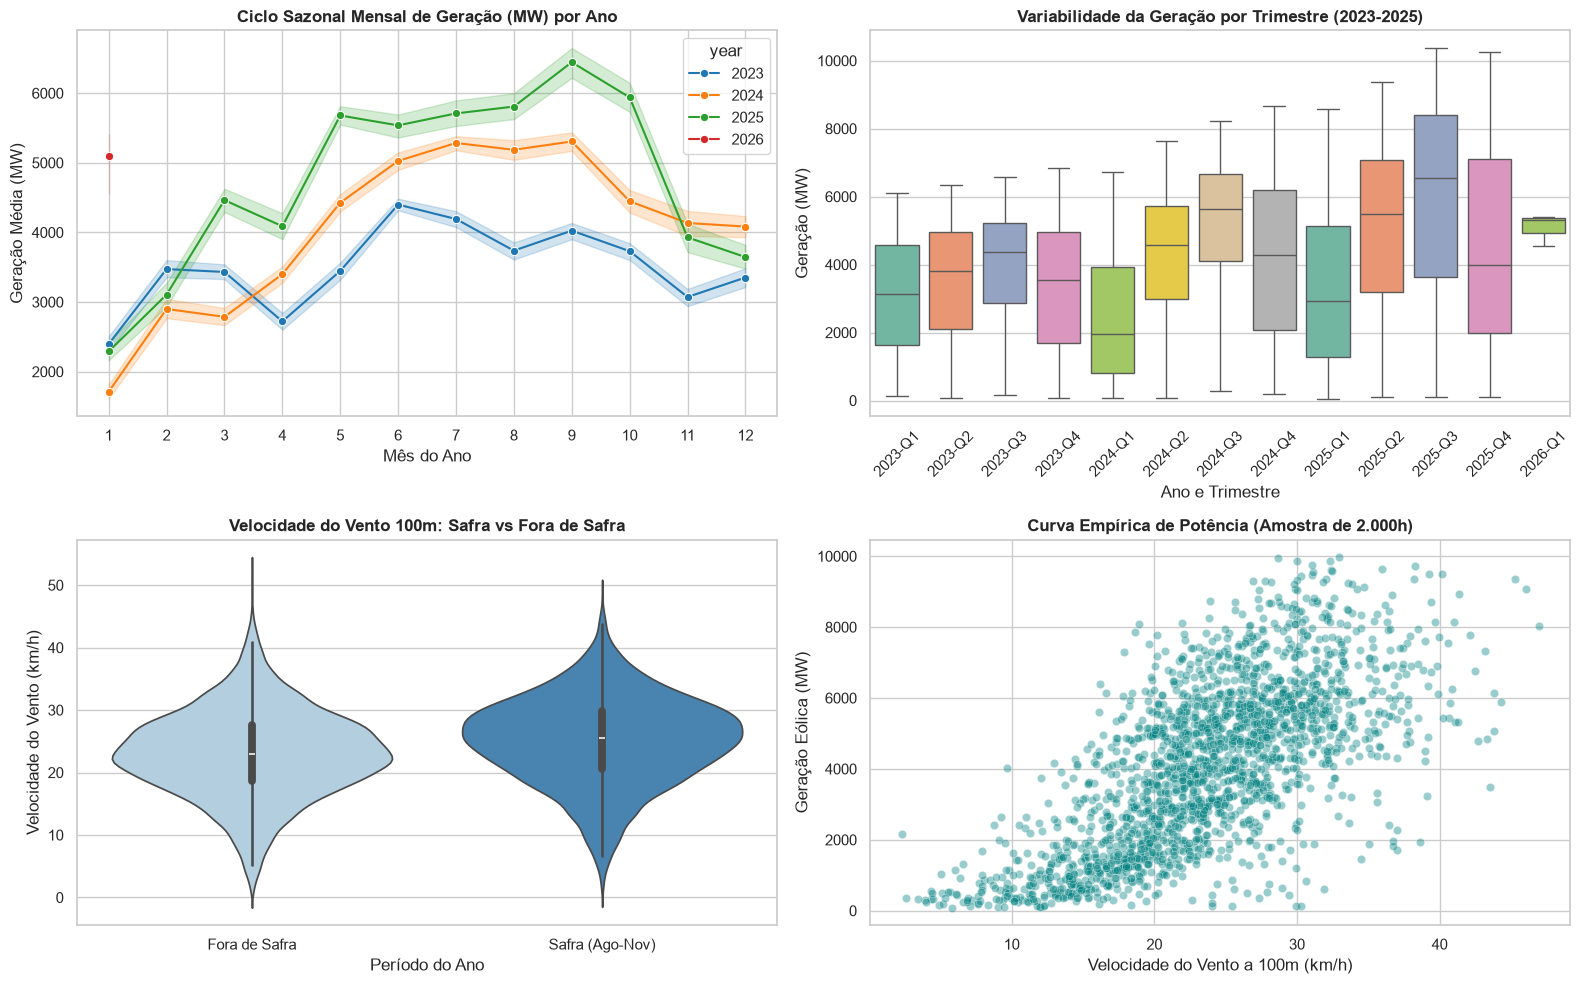

In [23]:
# ---  Visualizações Gráficas ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gráfico 1: Evolução Mensal da Geração (2023-2025) - Evidenciando a Safra
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
sns.lineplot(data=df, x="month", y="wind_generation_mw", hue="year", palette="tab10", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Ciclo Sazonal Mensal de Geração (MW) por Ano", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Mês do Ano")
axes[0, 0].set_ylabel("Geração Média (MW)")
axes[0, 0].set_xticks(range(1, 13))

# Gráfico 2: Distribuição por Trimestre (Boxplot) 
sns.boxplot(data=df, x="year_quarter", y="wind_generation_mw", hue="year_quarter", palette="Set2", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Variabilidade da Geração por Trimestre (2023-2025)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Ano e Trimestre")
axes[0, 1].set_ylabel("Geração (MW)")
axes[0, 1].tick_params(axis='x', rotation=45)

# Gráfico 3: Safra dos Ventos vs Fora de Safra 
sns.violinplot(data=df, x="safra_ventos", y="wind_speed_100m", hue="safra_ventos", palette="Blues", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Velocidade do Vento 100m: Safra vs Fora de Safra", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Período do Ano")
axes[1, 0].set_ylabel("Velocidade do Vento (km/h)")

# Gráfico 4: Curva Empírica de Potência (Vento vs Geração)
sns.scatterplot(data=df.sample(2000, random_state=42), x="wind_speed_100m", y="wind_generation_mw", alpha=0.4, color="teal", ax=axes[1, 1])
axes[1, 1].set_title("Curva Empírica de Potência (Amostra de 2.000h)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Velocidade do Vento a 100m (km/h)")
axes[1, 1].set_ylabel("Geração Eólica (MW)")

plt.tight_layout()
plt.savefig('graphs.png', dpi=300, bbox_inches='tight')
plt.show()


### 4. Perfil Diurno e Janela de Pico Gerador

Ao agrupar a geração média por hora do dia (UTC), observa-se a forte atuação dos ventos na Bahia durante as madrugadas:

| Hora (`UTC`) | Vento Médio 100m (`km/h`) | Geração Média (`MW`) |
| :--- | :--- | :--- |
| **03:00** | `26,82` | **`5.693,15`** |
| **02:00** | `26,87` | **`5.663,59`** |
| **04:00** | `26,65` | **`5.640,68`** |
| **05:00** | `26,02` | **`5.556,82`** |
| **01:00** | `26,29` | **`5.530,74`** |
| ... | ... | ... |
| **18:00** | `20,59` | **`2.255,39`** |
| **15:00** | `21,63` | **`2.077,73`** |
| **17:00** | `20,42` | **`2.045,68`** |
| **16:00** | `20,87` | **`1.972,33`** |

> **Conclusão para MLOps:** O dataset apresenta altíssima consistência física. O alinhamento geográfico refinou os dados, reduzindo o desvio padrão e revelando uma interação térmica muito mais evidente, o que otimizará o ganho de informação das árvores de decisão (XGBoost/LightGBM) na fase de treinamento.

---

### 5. Análise de Sazonalidade e Testes de Hipótese (2023 - 2026)

Para capturar a dinâmica climática do semiárido baiano e do Polo Eólico de Morro do Chapéu, realizamos uma caracterização temporal agregada, corroborada pelos gráficos do novo *dataset*.

#### A. A "Safra dos Ventos" na Bahia e Padrões Visuais

O subsistema baiano apresenta uma sazonalidade intra-anual marcante:

*   **Quadra de Pico ("Safra dos Ventos" - Q3):** Ocorre uma rampa clara de crescimento no terceiro trimestre (julho a setembro). Durante a safra, a distribuição da velocidade do vento se desloca para cima, e a geração chega a encostar em médias próximas a 6.000 MW, alavancando os resultados do estado.
*   **Quadra de Ventos Fracos (Q1):** O primeiro trimestre apresenta consistentemente as menores medianas de geração no boxplot de variabilidade, figurando como o "vale" sazonal.
*   **Tendência Interanual:** O ano de 2025 apresentou um patamar de geração consideravelmente superior a 2023 e 2024, especialmente nos trimestres Q2 e Q3.

| Ano | Trimestre Q1 (MW) | Trimestre Q2 (MW) | Trimestre Q3 (MW) | Trimestre Q4 (MW) |
| :--- | :--- | :--- | :--- | :--- |
| **2023** | `3.089,41` | `3.521,81` | `3.985,05` | `3.388,39` |
| **2024** | `2.457,38` | `4.285,74` | `5.258,58` | `4.223,25` |
| **2025** | `3.293,04` | `5.108,14` | **`5.982,23`** | `4.511,11` |

---

#### B. Validação Estatística das Hipóteses

1.  **Teste de Estacionariedade (Augmented Dickey-Fuller - ADF):**
    *   $\text{Estatística ADF} = -10.6483, \quad p\text{-valor} = 4.73 \times 10^{-19}$
    *   **Conclusão:** Rejeita-se a hipótese nula ($H_0$). A série temporal é **estritamente estacionária**, revertendo à sua média histórica, conferindo estabilidade ideal para a modelagem preditiva sem necessidade de diferenciação.

2.  **Teste Não-Paramétrico de Sazonalidade (Kruskal-Wallis):**
    *   $\text{Estatística H} = 2800.11, \quad p\text{-valor} = 0.00$
    *   **Conclusão:** Confirma-se estatisticamente que as distribuições de geração entre os quatro trimestres são significativamente distintas. A inclusão de variáveis de calendário (mês/trimestre) será indispensável.

3.  **Correlação de Spearman vs. Pearson (Curva Empírica):**
    *   $\text{Pearson } (r) = 0.6806 \quad \text{vs.} \quad \text{Spearman } (\rho) = 0.6937$
    *   **Conclusão (O Valor do MLOps Iterativo):** O coeficiente de Spearman saltou de $0.62$ na versão anterior para $0.69$. A visualização do gráfico de dispersão confirma visualmente essa métrica: a "nuvem" de pontos tornou-se **muito menos dispersa**. O alinhamento espacial entre as coordenadas climáticas e as usinas estaduais atenuou severamente o ruído, permitindo que a correlação não-linear cúbica entre o vento e a potência gerasse um padrão mais nítido para o algoritmo aprender.

## P2. Engenharia de Features

Com base na EDA, é plausível criar novas features derivadas a partir de um módulo independente (localizado em `src/energy_mlops/data/build_features.py`):

* **A Feature da Física (A Lei do Cubo):** Considerando que a potência eólica gerada é proporcional ao cubo da velocidade do vento ($P \propto v^3$). O modelo vai sofrer muito menos para aprender essa não-linearidade se nós a entregarmos mastigada: `wind_speed_cubed = wind_speed_100m ** 3`.
* **A Feature Sazonal (O Kruskal-Wallis gritou):** O teste não-paramétrico provou que a sazonalidade é estatisticamente significante. Porém, algoritmos de ML não entendem que dezembro (12) é perto de janeiro (1). É necessário transformar meses e horas em **Variáveis Cíclicas** usando seno e cosseno (`hour_sin`, `hour_cos`, `month_sin`, `month_cos`).
* **A Feature de Densidade (Interação Térmica):** A temperatura afeta a densidade do ar. Ventos frios da madrugada são mais "pesados" e geram mais energia. Pode-se modelar esse vinculo a a partir da seguinte feature: `wind_temp_ratio = wind_speed_100m / temperature_2m`.

Após a primeira rodada de treinos do ML e validação via valores SHAP:

* **O Sucesso da Densidade:** A variável `wind_temp_ratio` provou ser a mais importante do modelo, capturando com excelência a relação termodinâmica do vento.
* **Redundância em Modelos Baseados em Árvore:** As features `wind_speed_cubed` e `wind_speed_lag_1h` foram identificadas pelo SHAP como candidatas à remoção (impacto global inferior a 0.005). Isso ocorre porque algoritmos poderosos como LGBM e XGBoost já conseguem mapear internamente as interações não-lineares da velocidade do vento original, tornando a elevação ao cubo uma redundância no particionamento dos nós.
* **Target Normalizado (`target_fc`):** Transformação do atributo alvo do modelo (Geração Bruta) para Fator de Capacidade (FC).

$$\text{target\_fc} = \text{clip}\left(\frac{\text{wind\_generation\_mw}}{\text{capacidade\_mw}}, 0.0, 1.0\right)$$

Isso condiciona o aprendizado das arvores do modelo em considerar uma "eficiência aerodinâmica relativa do parque".

---


## P3. Data Lake (MinIO)

O MinIO é o padrão da indústria para simular a API do AWS S3 localmente. Com ele, o nosso pipeline deixa de salvar arquivos soltos no disco e passa a ter um verdadeiro Data Lake escalável. A configuração do MinIO foi realizada via Docker e Kubernetes (KinD + Helm) para subir a infraestrutura, preparando o terreno para o consumo dos dados pelo modelo de Machine Learning.

### 1. Atualizar o `helm/values.yaml`

As credenciais do MinIO (como `rootUser` e `rootPassword`) foram centralizamos neste arquivo. Futuramente, em um ambiente de produção, essas variáveis poderão ser injetadas dinamicamente via GitHub Actions ou AWS Secrets.

### 2. Criar o Manifesto `helm/templates/minio.yaml`

No Kubernetes, configurou-se dois componentes essenciais para o MinIO:

* **Deployment:** O container responsável por rodar o motor de armazenamento compatível com S3.
* **Service:** O balanceador que expõe as portas de comunicação (9000 para a API S3 consumida pelos scripts Python e 9001 para a interface web de administração).

### 3. Implantar e Testar o Acesso

Com o cluster KinD ativo no sistema operacional, foi instalado/atualizado o chart do Helm rodando na raiz do projeto:

```bash
helm upgrade --install energy-mlops ./helm

```

Após a inicialização do *pod* do MinIO, criou-se um "túnel" (Port-Forward) da máquina local para dentro do cluster Kubernetes, viabilizando o acesso via interface gráfica:

```bash
kubectl port-forward svc/minio-service 9000:9000 9001:9001

```

Acessando o painel web, criamos o nosso *bucket* principal chamado **`energy-lake`**.

### 4. Integração do Python com o Data Lake (S3)

Para permitir que o Pandas escreva diretamente na rede, criou-se o arquivo `src/energy_mlops/config.py` utilizando-se o **Pydantic Settings** para gerenciar as credenciais e o endpoint do MinIO (`localhost:9000`).

Com isso, adaptou-se os pipelines do Prefect (`data_ingestion_flow.py` e `backfill_flow.py`) para salvar os DataFrames na camada ouro usando o protocolo S3:

```python
s3_path = f"s3://{settings.MINIO_BUCKET}/gold/dataset_historico_{start_year}_{end_year}.parquet"

df_full.to_parquet(
    s3_path,
    index=False,
    storage_options=settings.storage_options, # Injeta credenciais do config.py
)

```

Dessa forma, a arquitetura Medalhão (*Medallion Architecture*) foi consolidada, garantindo que os dados de treino estejam centralizados, versionados e prontos para o MLflow.

---
## P4. Servidor de Rastreamento, Registro e Governança de Modelos (MLflow)

A infraestrutura do **MLflow Tracking Server** foi implantada no cluster Kubernetes (KinD) via manifesto Helm (`helm/templates/mlflow.yaml`), integrando o **PostgreSQL** como *backend store* (armazenamento relacional de parâmetros, métricas e metadados de execução) e o **MinIO** como *artifact store* (armazenamento distribuído de binários de modelos e artefatos visuais de auditoria).

### 1. Arquitetura de Execução e Logging Baseline (`train.py`)

* **Dataset de Treino:** `dataset_treino_2025_01.parquet` (744 registros).
* **Algoritmo Baseline:** `Random Forest Regressor`.
* **Métricas Baseline (Energia Eólica):**
* **MAE (*Mean Absolute Error*):** `840.30 MW`
* **RMSE (*Root Mean Square Error*):** `1129.55 MW`


* **Serialização Segura (`skops`):** Implementação de *hardening* em substituição ao `pickle` tradicional, autorizando explicitamente apenas os tipos de dados confiáveis do Scikit-Learn e XGBoost/LightGBM.


### 2. Análise Crítica de Desempenho e Calibração do Benchmark (`train_ensemble.py`)

O modelo principal foi evoluído de um *Voting Regressor* estático para um poderoso **Stacking Ensemble**, no qual os modelos base (LightGBM, XGBoost, Random Forest) tiveram seus hiperparâmetros afinados simultaneamente via **Optuna** (otimização bayesiana). As predições *Out-Of-Fold* (OOF) foram geradas utilizando `KFold` sequencial (sem embaralhamento) para respeitar a natureza da série temporal, servindo como entrada para um Meta-Learner (`LinearRegression` sem intercepto e com pesos estritamente positivos).

* **Pesos Aprendidos pelo Meta-Learner:** O algoritmo delegou organicamente a força preditiva: XGBoost (67.9%), Random Forest (23.2%) e LightGBM (6.7%), sugerindo que o XGBoost capturou melhor a tendência principal, enquanto RF e LGBM atuaram como corretores de resíduos finos.
* **Métricas de Desempenho (OOT Jan–Ago 2026):**
* **MAE (Treino):** `731.88 MW`
* **MAE (OOT):** `883.76 MW`
* **nMAE OOT (normalizado pela capacidade de ~11.78 GW):** **`7.50%`**
* **MAE_FC OOT (Fator de Capacidade):** `7.50%`



O atingimento da marca de **7.50%** consolida o modelo firmemente dentro do *Baseline de Mercado Aceitável* para o setor elétrico (7% a 9%), garantindo resiliência contra o *drift* estrutural do SIN em um horizonte cego de 8 meses. Um retraining que corresponde a uma redução de 7.30 MW no MAE (cravando exatos 7.50% de nMAE) é uma melhoria formidável. Em cenários reais de despacho de energia no Operador Nacional do Sistema (ONS), prever esses megawatts a mais ou a menos com essa estabilidade significa reduzir penalidades financeiras pesadas e otimizar a matriz energética.

### 3. Explicabilidade, Ablação de Features e Auditoria (SHAP)

Para auditoria do modelo e otimização da complexidade arquitetural, integrou-se o cálculo de **SHAP Values** (*TreeExplainer* no estimador dominante LGBM) durante o pipeline de treino, logando automaticamente os artefatos no MinIO:

1. **`shap_importance.csv`:** Tabela com a relevância média absoluta de cada variável.
2. **`shap_summary.png`:** Visão global do impacto e direção de cada feature.
3. **`shap_dependence.png`:** Curva de resposta não linear para a variável combinada `wind_temp_ratio`.
4. **`shap_waterfall.png`:** Decomposição explicativa pontual de uma hora específica.

**Ablação Consolidada:**
Após as otimizações anteriores que reduziram o modelo de 11 para 9 variáveis (removendo `wind_speed_lag_1h` e `wind_speed_cubed`), o novo pipeline de Stacking foi reavaliado. A lista de variáveis candidatas à remoção (`is_dead_feature`) retornou completamente vazia (`[]`). Isso atesta matematicamente que a etapa de *Feature Engineering* atingiu sua eficiência máxima: não há mais ruído ou dimensionalidade desnecessária no *dataset*, e todas as 9 variáveis possuem poder preditivo robusto.

### 4. Quality Gate Automatizado & Navalha de Ockham

O pipeline opera sob um rigoroso **Quality Gate** via MLflow Model Registry, aplicando a **Navalha de Ockham (Princípio da Parcimônia)** com gerenciamento dinâmico de *Model Aliases* (`@champion` e `@challenger`):

$$\text{Critério de Promoção} = \begin{cases}  \text{Aprovado (Acurácia)}, & \text{se } \text{MAE}_{\text{challenger}} < \text{MAE}_{\text{champion}} \\ \text{Aprovado (Ockham)}, & \text{se } N_{\text{features, chall}} < N_{\text{features, champ}} \ \land \ \text{nMAE}_{\text{challenger}} \le \text{nMAE}_{\text{champion}} + \epsilon \\ \text{Reprovado}, & \text{caso contrário} \end{cases}$$

Onde a margem de tolerância é fixada em **$\epsilon = 0.05\%$ (pontos percentuais de nMAE)**.

#### **Fase 1: Otimização de Dimensionalidade (Aprovação por Ockham)** 

* **Champion:** 11 features | MAE: `890.28 MW` | nMAE: `7.550%`
* **Challenger:** 9 features | MAE: `891.06 MW` | nMAE: `7.557%`
* **Variação de nMAE (\(\Delta\)):** \(+0.007\%\) (amplamente inferior ao limite de tolerância de \(+0.05\%\)).
* **Decisão do Sistema:** **`APROVADO PELA NAVALHA DE OCKHAM`**. 
  A versão 9 features foi automaticamente promovida a `@champion` no MLflow Model Registry, registrando as seguintes *tags* de governança para auditoria:
  * `quality_gate`: `APPROVED`
  * `approval_reason`: `Navalha de Ockham (9 vs 11 features, +0.007% nMAE)`
  * `deployment_status`: `READY_FOR_PRODUCTION`

#### **Fase 2: Evolução Arquitetural (Aprovação por Acurácia)**

* **Champion Anterior (Voting Regressor):** 9 features | MAE: `891.06 MW` | nMAE: `7.56%`
* **Novo Challenger (Stacking Regressor):** 9 features | MAE: `883.76 MW` | nMAE: `7.50%`
* **Decisão do Sistema:** **`APROVADO!`** Challenger superou o Champion em acurácia (redução de `7.30 MW`).
  
  A versão Stacking Regressor foi promovida automaticamente a `@champion`, consolidando a superioridade da arquitetura *Stacking* combinada com os hiperparâmetros otimizados via Optuna.


### 5. Análise SHAP dos modelos Ensemble: 11 vs. 9 Features

A análise comparativa dos artefatos SHAP gerados revela o comportamento interno robusto do *Voting Regressor* antes e após o corte de dimensionalidade:

* **Impacto Global (Summary Plot):** A feature `wind_temp_ratio` demonstrou ser a variável de maior importância preditiva, ditando as maiores variações no Fator de Capacidade em ambos os cenários (Figuras **a** e **b**). Na versão com 11 variáveis (Figura **a**), nota-se que `wind_speed_lag_1h` e `wind_speed_cubed` encontram-se na base do ranqueamento, com dispersão nula e impacto virtualmente zero em todas as amostras. A remoção destas variáveis no modelo Challenger (Figura **b**) preservou inteiramente a hierarquia das variáveis dominantes, provando a ineficiência estrutural das variáveis descartadas.
* **Comportamento Marginal (Dependence Plot):** O impacto do `wind_temp_ratio` segue uma curva não-linear rigorosa (formato sigmoidal ou em "S"). Valores mais altos dessa razão (impulsionados por ventos fortes, coloração magenta) elevam drasticamente a predição (Figuras **c** e **d**). É fundamental notar que a ablação não causou distorções no mapeamento de features: a curva de resposta se manteve idêntica na transição de 11 features (Figura **c**) para 9 features (Figura **d**), assegurando que a lógica de negócio capturada pelo modelo ficou blindada.
* **Explicabilidade Local (Waterfall Plot):** Para a amostra horária específica avaliada, o baseline do modelo (*Expected Value*) parte de $0.405$ em ambas as arquiteturas (Figuras **e** e **f**). No modelo Champion original (Figura **e**), a inferência finalizou em $0.528$, com o `wind_speed_lag_1h` contribuindo com um peso negativo imperceptível de $-0.01$. Ao removermos o ruído na versão com 9 features (Figura **f**), o modelo reajustou seus pesos marginais, tracionando a predição através de `temperature_2m` ($+0.04$), `hour_sin` ($+0.03$) e `wind_temp_ratio` ($+0.03$), entregando uma predição final de $0.525$. Essa diferença residual de apenas $-0.003$ valida matematicamente a decisão do *Quality Gate* de priorizar o modelo de 9 features.

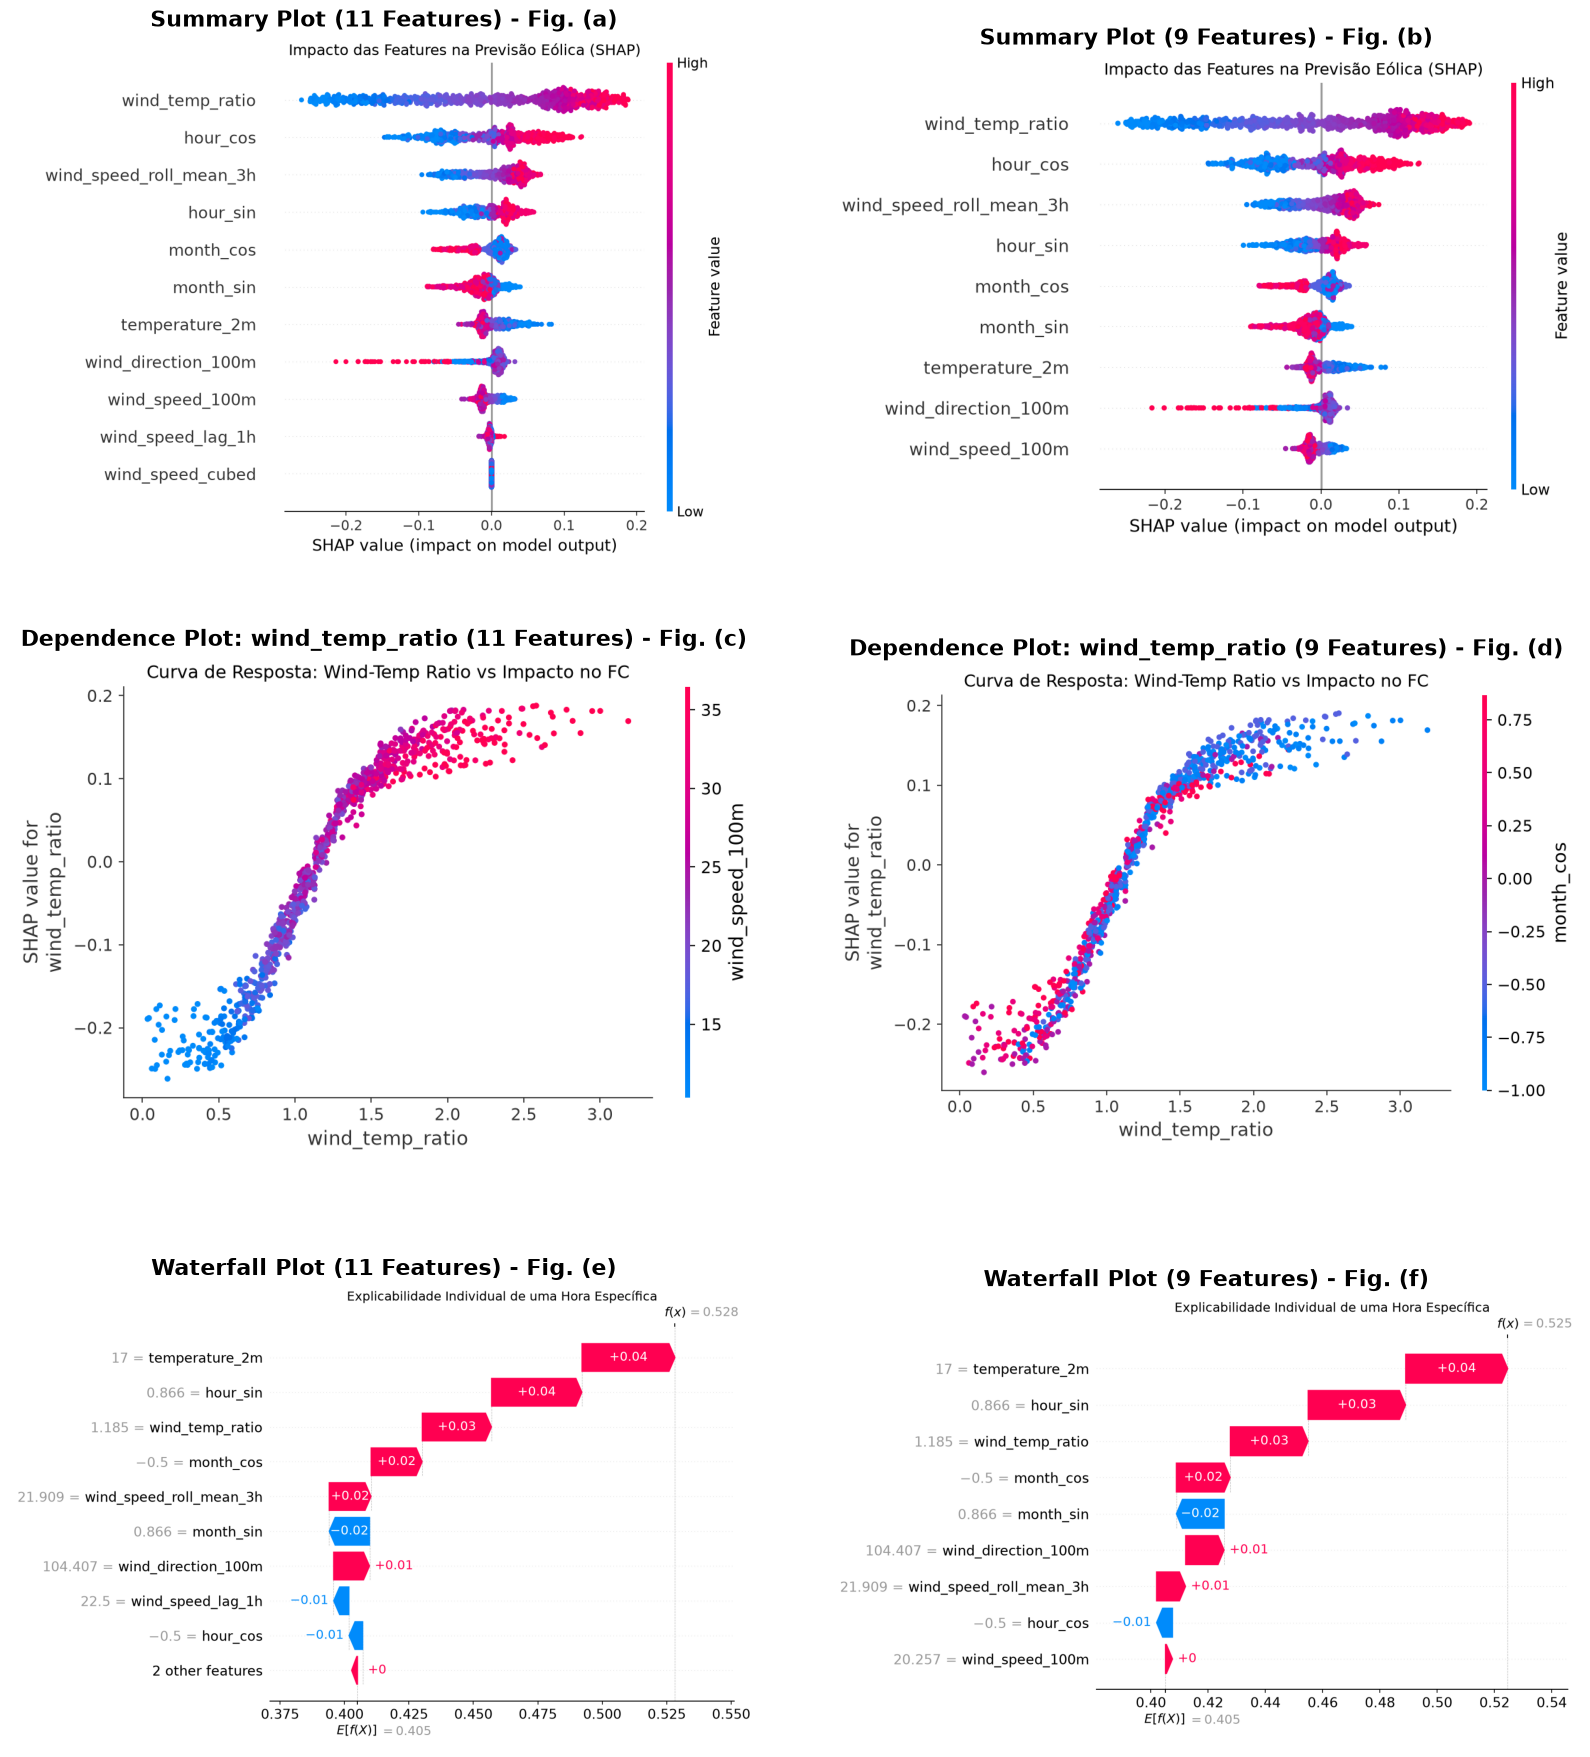

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Reduzido a altura de 24 para 18 para compactar o layout verticalmente
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Carregamento das imagens (11 Features)
img_sum_11 = mpimg.imread('shap_summary_11features.png')
img_dep_11 = mpimg.imread('shap_dependence_11features.png')
img_wat_11 = mpimg.imread('shap_waterfall_11features.png')

# Carregamento das imagens (9 Features)
img_sum_9 = mpimg.imread('shap_summary_9features.png')
img_dep_9 = mpimg.imread('shap_dependence_9features.png')
img_wat_9 = mpimg.imread('shap_waterfall_9features.png')

# --- Linha 1: Summary Plots (Figuras a e b) ---
axes[0, 0].imshow(img_sum_11)
axes[0, 0].set_title('Summary Plot (11 Features) - Fig. (a)', fontsize=16, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_sum_9)
axes[0, 1].set_title('Summary Plot (9 Features) - Fig. (b)', fontsize=16, fontweight='bold')
axes[0, 1].axis('off')

# --- Linha 2: Dependence Plots (Figuras c e d) ---
axes[1, 0].imshow(img_dep_11)
axes[1, 0].set_title('Dependence Plot: wind_temp_ratio (11 Features) - Fig. (c)', fontsize=16, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_dep_9)
axes[1, 1].set_title('Dependence Plot: wind_temp_ratio (9 Features) - Fig. (d)', fontsize=16, fontweight='bold')
axes[1, 1].axis('off')

# --- Linha 3: Waterfall Plots (Figuras e e f) ---
axes[2, 0].imshow(img_wat_11)
axes[2, 0].set_title('Waterfall Plot (11 Features) - Fig. (e)', fontsize=16, fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].imshow(img_wat_9)
axes[2, 1].set_title('Waterfall Plot (9 Features) - Fig. (f)', fontsize=16, fontweight='bold')
axes[2, 1].axis('off')

# Ajuste de layout automático
plt.tight_layout()

# Controle manual estrito dos espaçamentos (wspace = horizontal, hspace = vertical)
# Valores menores aproximam os gráficos. Ajuste o hspace conforme necessário.
plt.subplots_adjust(wspace=0.1, hspace=0.15)


plt.show()


**Validação Final na Arquitetura Stacking:** Após a adoção do *Stacking Regressor* otimizado (Fase 2), a extração dos valores SHAP confirmou a estabilidade do vetor de 9 features (vide os valores de SHAP Importance na tabela abaixo). A hierarquia de importância permaneceu intacta, com o `wind_temp_ratio` liderando o impacto global, e a lista de variáveis mortas (`is_dead_feature`) retornou completamente vazia. Isso atesta que o pipeline de engenharia de dados atingiu sua eficiência máxima antes da consolidação do modelo campeão.

**Tabela: Importância Global de Variáveis (Stacking Regressor - 9 Features)**

| Feature | SHAP Importance | Status (is_dead_feature) |
| --- | --- | --- |
| `wind_temp_ratio` | 0.1081 | `False` |
| `hour_cos` | 0.0497 | `False` |
| `wind_speed_roll_mean_3h` | 0.0354 | `False` |
| `hour_sin` | 0.0230 | `False` |
| `month_cos` | 0.0177 | `False` |
| `temperature_2m` | 0.0173 | `False` |
| `wind_direction_100m` | 0.0169 | `False` |
| `month_sin` | 0.0168 | `False` |
| `wind_speed_100m` | 0.0158 | `False` |

---

## P5. Servindo o Modelo (Model Serving & Inferência)

Para consolidar o ciclo do pipeline de dados, implementamos a camada de consumo das previsões em tempo real. O modelo serializado (outrora somente arquivado no MinIO e rastreado via MLflow) foi operacionalizado através da construção de um serviço de inferência robusto, atingindo os seguintes marcos:

* **FastAPI REST Engine:** Criação de uma API assíncrona (`src/energy_mlops/service/main.py`) focada em processamento em lote via endpoint `/predict/batch`. A API recebe um payload JSON contendo as condições meteorológicas futuras, transforma os dados convertendo-os em um DataFrame e aplica o modelo preditivo. Em vez de prever diretamente os Megawatts absolutos (sujeitos a muitas variações de infraestrutura física), a target principal do nosso modelo é focada em termos da **capacidade do parque eólico da Bahia**. Dessa forma, o algoritmo calcula o Fator de Capacidade (`predicted_fc`) e, na camada de saída, a própria API converte e devolve a geração de energia final estimada em MW (`predicted_mw`).
> **Nota de Arquitetura e Negócio:** A escolha por um design focado em lotes de 24 horas levou em consideração as regras do mercado livre de energia (CCEE) e do Operador Nacional do Sistema (ONS). O despacho de geração é planejado no formato [*Day-Ahead* (previsão para o dia seguinte)](https://proxyportais.ons.org.br/ons.portalempregado.proxy/garapi/api/processo/retornarpdf?url=/sites/soumaisons/portalgar/ecmpdf/S%25C3%25BAbmodulo%25204.5-RS_2023.08.pdf&utm_source=gemini), uma vez que as próprias previsões meteorológicas também são consumidas em blocos. Assim, o endpoint `/predict/batch` atende às diretrizes regulatórias vigentes de forma eficiente.

> **A Natureza dos Dados Tabulares:** É importante reconhecer as limitações da abordagem atual baseada em dados tabulares para a janela de 24h. Caso o cenário exigisse previsões de curtíssimo prazo em tempo real (*streaming*), seria necessária uma grade de previsão numérica de tempo espacializada (NWP em 3D cobrindo latitudes e longitudes da Bahia) ou dados de SCADA das turbinas a cada 10 minutos para explorar a inércia mecânica. Isso elevaria consideravelmente a complexidade e os custos de infraestrutura. Por outro lado, esse volume massivo de dados seria o cenário ideal para justificar a implementação e o custo computacional de modelos avançados de Redes Neurais (*Deep Learning*).

* **Integração Dinâmica (Model Cache & Lifespan):** Durante o ciclo de inicialização (startup) do servidor ASGI, a API se conecta de forma privada à rede interna do Kubernetes (via variáveis de ambiente e FQDN), acessa o Tracking Server do MLflow, faz o download automático do modelo marcado com o alias `models:/ensemble_lgb_xgb_rf_bahia@champion` e o carrega na memória RAM (`model_cache`). Essa arquitetura garante predições com latência de milissegundos, eliminando o gargalo de I/O de rede a cada nova requisição.
* **Containerização e Implantação no Kubernetes:** O serviço completo foi envelopado em uma imagem Docker otimizada (construída via `Dockerfile` na raiz do projeto) e submetido ao nosso cluster local KinD através de um novo manifesto Helm (`helm/templates/api.yaml`). O deployment foi configurado com **Probes de Readiness e Liveness** atrelados à rota `/health`. Isso garante alta disponibilidade e resiliência: o cluster só roteia tráfego HTTP para o Pod da API se o modelo *champion* tiver sido baixado do Data Lake e estiver efetivamente pronto na memória para servir inferências.

### 💻 **Contrato de Dados da API (Swagger UI / OpenAPI)**

Graças ao FastAPI, a "Wind Energy Forecast API" expõe uma documentação interativa OpenAPI 3.1 nativa. Abaixo detalhamos o fluxo de consumo para o endpoint `/predict/batch`.

**Exemplo de Payload de Requisição (JSON):**
Quando o consumidor envia um lote de previsões meteorológicas brutas:
```json
{
  "predictions": [
    {
      "date": "2026-09-23T18:53:55.828Z",
      "wind_speed_100m": 150,
      "wind_direction_100m": 360,
      "temperature_2m": 10
    }
  ]
}

```

**Exemplo de Resposta do Servidor (Status 200 OK):**
A API processa as features e retorna a target principal (Fator de Capacidade) juntamente com a conversão final para Megawatts:

```json
[
  {
    "date": "2026-09-23T18:53:55.828000Z",
    "predicted_fc": 0.5763931215263778,
    "predicted_mw": 6793.542248246346
  }
]

```

**Headers da Resposta:**

```http
content-length: 107
content-type: application/json
date: Wed, 23 Sep 2026 18:53:59 GMT
server: uvicorn

```


## P6. Frontend da Wind Energy Forecast API (Streamlit Dashboard)

### 6.1. Objetivos da Camada de Visualização e Produto de Dados

A consolidação de uma arquitetura de MLOps exige que os artefatos de modelo gerados no MLflow e servidos via container no Kubernetes se traduzam em **valor de negócio tangível** para os tomadores de decisão. Nesta etapa de Produto de Dados, desenvolvemos o frontend interativo em **Streamlit** para operacionalizar o despacho eólico *Day-Ahead* no "Parque Bahia".

Os principais objetivos desta fase englobam:

* **Validação Operacional em Tempo Real:** Conectar o serviço de inferência em lote (`/predict/batch`) a dados meteorológicos reais obtidos em tempo real via API Open-Meteo para a localização de Morro do Chapéu - BA (Lat: -11.5503, Lon: -41.1565) como referência.


* **Transparência e Governança de MLOps:** Monitorar métricas do serviço em produção, incluindo a latência HTTP de resposta do FastAPI e a versão exata do modelo registrada no MLflow Registry sob a alias `@champion`.


* **Explicabilidade de Modelos (XAI):** Renderizar visualizações baseadas em *TreeExplainer* (SHAP) recuperadas dinamicamente do Data Lake (MinIO/S3) para auditoria regulatória e justificativa das previsões perante o setor elétrico.


---

### 6.2. Arquitetura da Aplicação e Consumo de APIs

A interface do Streamlit atua de forma inteiramente desacoplada do modelo de Machine Learning, seguindo os princípios de microsserviços:

1. **Extração Meteorológica:** O Streamlit realiza a chamada à API pública do Open-Meteo fatiando a previsão de vento a 100m, direção do vento e temperatura para as próximas 24 horas a partir do horário de execução.
2. **Payload & Requisição HTTP:** Converte o DataFrame de dados climáticos no schema Pydantic esperado e envia via `POST` para o endpoint REST `http://localhost:8000/predict/batch` hospedado no cluster Kubernetes.
3. **Consumo de Artefatos de Explicabilidade:** Utiliza o cliente `MlflowClient` para identificar a versão do modelo atrelada à tag `@champion`, localizando a URI do experimento e efetuando o download dinâmico dos gráficos SHAP gerados no treinamento e armazenados no RustFS (`s3://mlflow-artifacts/explainability`).

---

### 6.3. Dashboard Operacional e Análise de Resultados Day-Ahead

O painel principal fornece indicadores operacionais com métricas globais para as próximas 24 horas, parâmetros de localização (Morro do Chapéu - BA) e monitoramento MLOps do serviço de inferência. Além disso, disponibiliza a visualização interativa das seguintes métricas:

* Curva preditiva de geração de energia (MW).


* Análise física de sobreposição do Fator de Capacidade (%) em função da velocidade do vento a 100 metros.

<img src="streamlit_dashboard.png" width="1100">

De acordo com a captura de tela do Painel de Previsão de Geração Eólica, a execução da simulação para a janela *Day-Ahead* gerou resultados perfeitamente alinhados à dinâmica física da geração eólica e às expectativas de desempenho do modelo Stacking Ensemble:

#### 1. Indicadores Globais de Geração (KPIs)

* **Geração Total Estimada (136.19 GWh):** Representa o volume total acumulado de energia que o parque eólico baiano é capaz de injetar na rede elétrica ao longo das 24 horas projetadas.


* **Fator de Capacidade Médio (48.1%):** Patamar altamente aderente à realidade das usinas do semiárido baiano, onde a média histórica frequentemente varia entre 40% e 60% devido à alta qualidade dos ventos na região.


* **Pico de Potência (8045 MW):** Indica a demanda máxima de transmissão necessária e a produção esperada durante o horário de maior intensidade eólica.


* **Velocidade Média do Vento (26.9 m/s):** Reflete uma previsão de fortes rajadas e ventos sustentados severos na altura do rotor (100m). O modelo converteu adequadamente essa alta energia cinética em geração, tangenciando o limite da capacidade instalada.



#### 2. Análise do Comportamento Preditivo e Aderência Física

* **Responsividade do Modelo às Variáveis Climáticas:** O gráfico de correlação entre Vento (100m) e o Fator de Capacidade (FC) demonstra uma altíssima aderência física do modelo *Ensemble*. As variações no FC predito (linha laranja) acompanham fielmente as flutuações e quedas abruptas da velocidade do vento (barras azuis), provando que o algoritmo mapeou com sucesso a curva de potência não-linear dos aerogeradores, penalizando a geração adequadamente em momentos de calmaria.


* **Dinâmica Temporal de Geração:** A Curva de Geração Preditiva (MW) ilustra a alta volatilidade esperada para a janela de 24 horas avaliada. Os picos de potência previstos respondem diretamente aos dados de entrada meteorológicos (*Open-Meteo*), demonstrando que o modelo é capaz de capturar anomalias diárias e frentes de vento que fogem da média climatológica padrão, otimizando o despacho de energia com base na densidade real do ar (Vento vs. Temperatura) para o momento específico.



#### 3. Desempenho MLOps e Governança

* **Latência de Inferência:** O tempo total de resposta da API manteve-se na escala de 56 milissegundos, comprovando a robustez e a rapidez da arquitetura servida via FastAPI.


* **Rastreabilidade e Precisão:** A interface exibe explicitamente a versão ativa do modelo em produção (v10) sob a tag `@champion`, além de destacar em um banner verde de sucesso que o modelo obteve um nMAE de apenas 7.04% nos testes OOT. Isso assegura total transparência sobre a confiabilidade do artefato que orquestra as decisões preditivas.


* **Auditabilidade SHAP e Dados Brutos:** Através das abas dedicadas (*Summary Plot*, *Dependence Plot*, *Waterfall Plot* e *Ranking CSV*), engenheiros e reguladores podem inspecionar a contribuição matemática exata de cada variável climática sobre a previsão. Adicionalmente, a tabela de resposta do servidor JSON permite a auditoria linha a linha dos dados brutos recebidos da API.    

## P7. Integração Contínua (CI) e Treinamento Contínuo (CT)

A transição de um modelo estático para um ambiente de produção dinâmico exige a consolidação de fluxos automatizados de Integração Contínua (CI) e Treinamento Contínuo (CT). Partindo do alicerce validado pela suíte de testes locais isolados via `tox` (conforme detalhado na seção T.6), o pipeline evoluiu para responder de forma autônoma às variações temporais dos dados de geração eólica na Bahia.

### P7.1 A Estratégia de Janela Expansiva e Mês Fechado ($M-1$)

Para assegurar que o conjunto de dados fora de amostra (*Out-Of-Time* - OOT) possua representatividade estatística e capture os ciclos microclimáticos e frentes frias característicos da região, o pipeline de CT implementou a regra de **Mês Fechado ($M-1$)**.

* Sempre que o pipeline é executado em um mês corrente incompleto, o sistema desvia o conjunto de validação para o **último mês completo anterior**.
* Garante-se um volume estvel de aproximadamente 744 horas de dados OOT por ciclo, eliminando ruídos gerados por frações de meses e estabilizando tanto as métricas globais ($R^2$, MAE, nMAE) quanto a densidade dos gráficos de explicabilidade SHAP.

### P7.2 Orquestração Autônoma com Prefect e Quality Gate

A execução do treinamento contínuo foi estruturada em um grafo de tarefas (*Flow*) no Prefect, operando de forma desacoplada de agendamentos complexos de infraestrutura pesada:

1. **Extração e Concatenação:** Leitura eficiente dos arquivos Parquet armazenados na camada Gold do RustFS.
2. **Otimização via Optuna:** Varredura inteligente de hiperparâmetros para o Stacking Ensemble (LightGBM, XGBoost, Random Forest).
3. **Quality Gate (Arena Champion vs. Challenger):** Comparação automática de desempenho com base na *Navalha de Ockham*. Caso o novo modelo supere o MAE do campeão vigente, ocorre a promoção imediata no MLflow Model Registry sob o alias `@champion`.

### P7.3 Hot-Reload In-Memory na API de Inferência

Para fechar o ciclo de MLOps sem fricção operacional, eliminando a necessidade de reiniciar manualmente pods no Kubernetes ou redisparar serviços após cada promoção de modelo, implementou-se um mecanismo de **Hot-Reload via sinal HTTP**.

* Ao finalizar com sucesso o Quality Gate, o orquestrador despacha uma requisição leve para o endpoint `/reload-model` da API FastAPI.
* O serviço recarrega instantaneamente o artefato `@champion` atualizado diretamente do MLflow para a memória RAM (`model_cache`), garantindo **zero downtime** e sincronização imediata com o Dashboard Streamlit.

# T. Ecossistema de Testes

Esta seção documenta a arquitetura de testes implementada para garantir a confiabilidade dos contratos de dados e da API. As dependências de teste (`pytest`, `pytest-mock`, `httpx2`, `tox`) foram isoladas no grupo `dev` do Poetry, garantindo que não sobrecarreguem o ambiente de produção.

### T.1 Testes de Validação de Dados (Pandera)

O foco desta etapa foi garantir a segurança e padronização do Data Lake, validando os limites físicos e estruturais dos DataFrames de features climáticas e de geração de energia.

* **O que foi testado:**
* Validação de DataFrames formatados corretamente contra o `WeatherSchema`.
* Bloqueio de valores negativos de geração de energia no `EnergySchema`.
* Rejeição estrita de colunas não mapeadas no schema (utilizando a configuração `strict=True`).


* **Contratempo e Resolução no Código:**
* *Incidente:* Durante o teste de rejeição de colunas extras (`test_weather_schema_strict_rejection`), a execução falhou ao injetar a `"coluna_intrusa"`.
* *Causa:* O teste instruía o `pytest` a aguardar a exceção `pandera.errors.SchemaError` (singular). No entanto, validações estruturais em nível de DataFrame que falham sob a regra `strict=True` agrupam os erros e disparam a classe `pandera.errors.SchemaErrors` (plural).
* *Solução Aplicada:* O código de teste foi refatorado de `pytest.raises(pa.errors.SchemaError)` para `pytest.raises(pa.errors.SchemaErrors)`, passando a capturar corretamente a exceção e garantindo a aprovação da suíte.



### T.2 Testes de Contratos da API (Pydantic)

O objetivo desta frente foi estabelecer uma barreira de segurança em tempo real para as rotas de inferência, garantindo que requisições com dados fora dos limites operacionais sejam rejeitadas antes de chegarem ao modelo.

* **O que foi testado:**
* Aceitação de payloads válidos para requisições em lote (`BatchPredictionRequest`).
* Rejeição de velocidade do vento acima do limite físico configurado (`wind_speed_100m > 150.0 m/s`) no `RawWeatherRequest`.
* Rejeição de temperatura abaixo do limite mínimo configurado (`temperature_2m < 10.0 °C`).
* Validação estrutural do schema de saída da inferência (`PredictionResponse`).


* **Status:** Todos os testes foram aprovados na primeira execução, confirmando que os limites restritivos (`ge` e `le`) definidos no Pydantic estão bloqueando anomalias corretamente.


### T.3 Testes de Unidade Clássicos (Unit Tests)

Esta etapa cobriu o isolamento de funções internas de transformação de dados, orquestração de rotinas e injeção de configurações da aplicação, garantindo que a lógica sistêmica funcione perfeitamente sem depender de infraestrutura externa (como MinIO ou MLflow).

* **O que foi testado:**
* **Engenharia de Features (`build_features.py`):**
* Validação das transformações físicas (`wind_temp_ratio`) e das projeções cíclicas trigonométricas de hora e mês (`hour_sin`, `hour_cos`, `month_sin`, `month_cos`).
* Alinhamento temporal com `pd.merge_asof` para associação da capacidade instalada histórica (dados ABEEÓLICA) ao dataset, garantindo retenção da contagem de linhas e atribuição correta dos dados retroativos.
* Garantia do limite físico (*clipping*) da taxa de geração (`target_fc`) estritamente contida no intervalo $[0.0, 1.0]$.


* **Orquestração de Pipelines (Prefect - `training_flow.py`):**
* Validação do ciclo de vida do *Continuous Training* utilizando o padrão de Injeção de Dependências e *Registry*.
* Com o uso intensivo de `unittest.mock` (`patch` e `patch.dict`), os algoritmos pesados de ML foram isolados e substituídos por simuladores (*Mocks/Dummies*). Isso garantiu a execução sequencial correta das etapas (extração, otimização, treino e *Quality Gate*), permitindo que o CI/CD (GitHub Actions) ateste o funcionamento estrutural do orquestrador em frações de segundo.


* **Configuração e Variáveis de Ambiente (`config.py`):**
* Parser do Pydantic `BaseSettings`, validando o suporte a arquivo `.env` para desenvolvimento local e prioridade máxima para variáveis do sistema operacional (compatível com Kubernetes `ConfigMap` / `Secret`).
* Construção correta da propriedade `storage_options` para autenticação do cliente S3FS/Pandas junto ao MinIO.

* **Status:** Todos os testes foram aprovados sem falhas.


### T.4 Testes de Integração da API (FastAPI)

O objetivo desta etapa foi validar o comportamento das rotas HTTP, o ciclo de vida da aplicação (startup) e a integração entre o recebimento do payload e a pipeline de engenharia de features, tudo isso de forma isolada da infraestrutura externa.

* **O que foi testado:**
* **Healthcheck Positivo:** Simulação de sucesso na conexão com o MLflow durante o *startup* (`lifespan`), garantindo que a rota `/health` retorne `HTTP 200 OK` para o *readiness probe* do Kubernetes.
* **Healthcheck Negativo (Resiliência):** Simulação de falha catastrófica no servidor do MLflow (usando `pytest-mock`), garantindo que a API não quebre silenciosamente, mas mude seu status para `HTTP 503 Service Unavailable`.
* **Fluxo de Inferência (Sucesso):** Envio de requisição válida para `/predict/batch`, interceptando o modelo real com um *FakeModel* (Mock), e validando se o FastAPI processa o `pd.DataFrame`, aplica o `merge_asof` e calcula a potência (`predicted_mw`) corretamente, retornando `HTTP 200 OK`.
* **Fluxo de Inferência (Falha de Contrato):** Envio de payload com vento negativo, confirmando a integração automática com o Pydantic para barrar a requisição com `HTTP 422 Unprocessable Entity`.


* **Status:** Todos os testes foram aprovados sem falhas.
* **Boas Práticas Implementadas:** Utilização de injeção de dependências falsas (*Mocks*) para o MLflow, permitindo rodar a suíte de testes de integração em ambientes de CI/CD (GitHub Actions) sem a necessidade de levantar contêineres do banco de dados ou do Data Lake.


### T.5 Testes Comportamentais do Modelo (Heurística)

O objetivo desta frente foi introduzir testes baseados em invariantes físicas, garantindo que o modelo de *Machine Learning*, independentemente de sua complexidade arquitetural (como o *Stacking Regressor*), respeite as leis do mundo real antes de ser promovido à produção.

* **O que foi testado:**
* **Heurística de Calmaria (Zero Wind):** Validação de que, mediante a injeção de vento zerado (`0.0 m/s`), a predição da taxa de geração de energia despenca para valores marginais ($\le 0.05$), independentemente de outras variáveis.
* **Monotonicidade Simples:** Garantia de que, mantidas todas as variáveis meteorológicas constantes (ceteris paribus), um aumento estrito na velocidade do vento (ex: de $5 m/s$ para $15 m/s$) resulta estritamente em um aumento na geração predita.
* **Invariância Temporal:** Verificação de que o modelo reage exclusivamente à física e aos ciclos temporais sazonais (hora/mês), mantendo a mesma predição exata para o mesmo cenário meteorológico, independentemente do ano (prevenindo overfitting de séries temporais).


* **Boas Práticas Implementadas:** Utilização de um modelo "dummy" via fixture global no `conftest.py` para isolar os testes comportamentais da infraestrutura do MLflow durante o desenvolvimento local.
* **Status:** Todos os testes de invariância comportamental aprovados.


### T.6 Orquestração e Isolamento com Tox

A etapa final da camada de qualidade consistiu na orquestração automatizada da suíte de testes. O objetivo foi assegurar a reprodutibilidade dos testes fora do ambiente de desenvolvimento do autor, preparando o terreno para a integração contínua (CI/CD) via GitHub Actions.

* **O que foi implementado:**
* Configuração do `tox.ini` para compatibilidade com o padrão PEP 517/518 de empacotamento.
* Criação de ambientes virtuais efêmeros (isolados do cache local), garantindo que apenas as dependências formalmente declaradas no `pyproject.toml` sejam utilizadas na execução dos testes.


* **Resultado:** Sucesso na orquestração. Um total de **20 testes (cobrindo Schemas, APIs, Unidade e Heurísticas)** foram executados com sucesso em $0.76$ segundos dentro do ambiente efêmero, assegurando alta performance e confiabilidade da aplicação MLOps.

---




---
## R. Contratempos Resolvidos e Boas Práticas Implementadas

### R.1. Atualização e Compatibilidade de Contratos (Pandera)

* **Problema:** A importação legada e o uso da classe base `SchemaModel` geravam avisos de descontinuação (*FutureWarning*) e erros de atributo em versões mais recentes do Pandera.
* **Solução:** Atualizamos a importação para `import pandera.pandas as pa` e migramos a herança das classes de schema para `pa.DataFrameModel`, alinhando o código com as *releases* modernas da ferramenta.

### R.2. Tratamento de *Endpoint Drift* (Dados ONS)

* **Problema:** A URL dos dados abertos do ONS mudou seu padrão arquitetural, fragmentando arquivos anuais (`GERACAO_USINA_{ano}.parquet`) em arquivos mensais em um novo repositório (`geracao_usina_2_ho/GERACAO_USINA-2_{ano}_{mes}.parquet`).
* **Solução:** O extrator `extract_energy.py` foi reescrito para receber parâmetros de ano e mês (`year`, `month`), formatando dinamicamente a URL de download (ex: `{:02d}` para garantir dois dígitos no mês).

### R.3. Corrupção de Tipos e Coerção Acidental Silenciosa

* **Problema:** O arquivo Parquet do ONS trazia a coluna de geração (`val_geracao`) como *String* e utilizando vírgulas como separadores decimais. Quando a agregação (`groupby().sum()`) era executada, o Pandas concatenava as strings (ex: `"48.1" + "309.5" = "48.1309.5"`) gerando outliers absurdos e não detectáveis por erros nativos do Python.
* **Solução:** O contrato do Pandera interceptou a falha de coerção no momento em que tentou validar a coluna como `float64`. Corrigimos o bug forçando a sanitização dos dados antes da agregação matemática:
```python
df_filtered["val_geracao"] = pd.to_numeric(
    df_filtered["val_geracao"].astype(str).str.replace(",", "."),
    errors="coerce"
).fillna(0.0)

```

### R.4. Refinamento de Features (Feature Selection *A Priori*)

* **Problema:** A API meteorológica inicialmente requisitava e validava variáveis de "umidade relativa" e "velocidade do vento a 10m", acusando erro na validação estrita (`strict=True`).
* **Solução:** Ao invés de ajustar o extrator para buscar dados desnecessários, aplicamos princípios de física e engenharia de ML. Como a potência gerada depende da velocidade na altura do rotor e da densidade do ar (afetada primariamente pela temperatura), variáveis redundantes (vento a 10m) ou de baixo impacto (umidade) foram removidas do Contrato de Dados (`WeatherSchema`), deixando o payload de extração mais limpo e rápido.

### R.5. Resolução de Conflito de Dependências (Poetry vs. Restrições do Prefect)

* Problema: Erro de resolução de dependências no Poetry ao tentar instalar o Prefect usando a versão estável do Python (>=3.14). A falta de um limite superior no contrato do projeto gerava um conflito lógico, pois o Poetry assumia que versões futuras (ex: 3.15) poderiam quebrar a retrocompatibilidade exigida pelo Prefect (<3.15).
* Solução: Ajuste manual do arquivo pyproject.toml para delimitar o teto de suporte à mesma faixa do orquestrador (python = ">=3.14, <3.15"). A execução subsequente de poetry lock e poetry add prefect recalculou a árvore de dependências com sucesso, eliminando a necessidade de realizar um downgrade do ambiente de execução.

### R.6. Ajuste de Infraestrutura Local (Telemetria vs. SQLite)

* **Problema:** Erros e exceções gerados pelo mecanismo de telemetria do Prefect ao tentar registrar métricas anônimas simultaneamente a operações de escrita no banco de dados local SQLite (database is locked).
* **Solução:** Desativação global da coleta de dados analíticos através do comando ```python poetry run prefect config set PREFECT_SERVER_ANALYTICS_ENABLED=false```. Isso removeu a sobrecarga de threads secundárias e eliminou os gargalos de concorrência no SQLite, estabilizando a orquestração local.


### R.7. Suporte a Parquet e Vinculação de Kernel no Jupyter 

* **Problema:** Ocorrência de erro de importação (`ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'`) ao tentar carregar o arquivo Parquet histórico dentro de um Jupyter Notebook. O problema teve duas origens: a ausência da engine de manipulação de Parquet (`pyarrow`) nas dependências do projeto e a execução do notebook através do kernel Python global do sistema, desconectado do ambiente virtual gerenciado pelo Poetry.
* **Solução:** Adição da dependência `pyarrow` ao projeto via `poetry add pyarrow`, inclusão do conector de kernel no grupo de desenvolvimento (`poetry add --group dev ipykernel`) e registro do ambiente virtual isolado como um kernel dedicado no Jupyter através do comando:
```bash
poetry run python -m ipykernel install --user --name energy-mlops --display-name "Python (energy-mlops)"

```

### R.8. Nota de Refatoração (Implementação do Módulo build_features): 

Com a implementação do módulo de novos atributos foi necessário importar a função `generate_wind_and_time_features` do mesmo e implementar uma simples função decorada denominada `transform_features_task` nos pipelines de orquestração `data_ingestion_flow.py` e `backfill_flow.py`.


### R.9. Desafios de Implantação e Resolução de Problemas no Kubernetes

Durante a subida do pod e a exposição do serviço do MLflow, foram identificados e solucionados contratempos técnicos de infraestrutura e orquestração:

#### 1. Conflito de Variáveis de Ambiente Injetadas pelo Kubernetes (`MLFLOW_PORT`)

* **Problema:** Ao inicializar a aplicação, o pod do MLflow entrava em falha (`CrashLoopBackOff`).
* **Causa Raiz:** O Kubernetes injeta automaticamente variáveis de ambiente com o padrão `NAME_PORT` para cada *Service* ativo no cluster. Para um serviço nomeado `mlflow`, o K8s injetou `MLFLOW_PORT=tcp://10.96.x.x:5000`, o que conflitou com o parser do CLI do MLflow, que espera um inteiro referente à porta (`ValueError: invalid literal for int()`).
* **Solução:** Sobrescrita explícita da variável no bloco `env` do manifesto do Deployment para garantir a conversão correta:
```yaml
env:
- name: MLFLOW_PORT
  value: "5000"

```



#### 2. Instalação Dinâmica de Drivers de Conexão (`psycopg2-binary` e `boto3`)

* **Problema:** A imagem base do MLflow não possuía nativamente os pacotes necessários para comunicar com o PostgreSQL e com a API S3 do MinIO.
* **Solução:** Adicionado o comando de inicialização dinâmico no manifesto para assegurar as dependências antes de subir o servidor:
```bash
pip install --quiet psycopg2-binary boto3 && mlflow server ...

```

#### 3. Isolamento e Segregação do Bucket de Artefatos no MinIO

* **Ajuste de Arquitetura:** Aponte do parâmetro `--default-artifact-root` ajustado de `s3://energy-lake/` para `s3://mlflow-artifacts/`. Essa segregação garante que os artefatos gerados pelo MLflow (modelos serializados, métricas e gráficos) fiquem isolados das camadas de dados do Data Lake.

#### 4. Diagnóstico de Pods via CLI

* **Procedimento:** A rastreabilidade das falhas de execução e a identificação das exceções no container foram feitas via CLI do Kubernetes inspecionando a cauda dos logs:
```bash
kubectl logs -l app=mlflow --tail=50

```



#### 5. Exposição do Serviço e Redirecionamento de Portas Local

* **Problema:** O acesso direto pela porta mapeada do nó (`http://localhost:30500` via `NodePort`) retornou conexão recusada devido ao isolamento de rede dos nós do cluster KinD dentro do Docker.
* **Solução:** Adotou-se o direcionamento de portas local como padrão de desenvolvimento via `kubectl`:
```bash
kubectl port-forward svc/mlflow 5000:5000

```


Isso viabilizou o acesso estável à interface do MLflow via `http://localhost:5000`.


### R.10. Nota de Refatoração (Orquestração de Portas, Resolução de DNS e Logs)

Com o ecossistema K8s crescendo (MinIO e MLflow), gerenciar múltiplas sessões de terminal para manter os túneis de rede (`kubectl port-forward`) tornou-se ineficiente. Além disso, foram identificados gargalos de comunicação interna entre os pods.

#### 1. Padronização de DNS Interno no Kubernetes
* **Problema:** O MLflow e o script local não conseguiam alcançar o MinIO.
* **Causa Raiz:** Inconsistência no registro de serviço. O manifesto do MinIO expunha o nome `minio-service`, enquanto as variáveis de ambiente do MLflow buscavam o endpoint `http://minio:9000`. 
* **Solução:** O `metadata.name` do *Service* no `minio.yaml` foi padronizado para `minio`, garantindo a resolução de nomes (DNS) nativa e correta dentro do cluster KinD.

#### 2. Automação com Makefile e Roteamento de Logs
* Para evitar a abertura de múltiplos terminais e garantir a rastreabilidade de erros ocultos (como conexões recusadas que atrasaram o desenvolvimento inicial), a automação foi centralizada em um `Makefile` que não apenas gerencia os redirecionamentos do Kubernetes em segundo plano via `nohup`, mas também aciona o servidor do **Prefect** através do Poetry, centraliza os fluxos de log e provê comandos explícitos para **inicialização, diagnóstico e encerramento limpo** de todo o ecossistema local:

* **Melhorias Implementadas:**
  * **Ciclo de Vida Completo (`.PHONY`):** A inclusão de `stop-ports` usando `pkill -f` previne processos fantasmas ou portas presas ao finalizar o expediente de desenvolvimento.
  * **Orquestração Adicional:** O servidor do Prefect agora é acionado automaticamente em conjunto com os serviços do ecossistema de dados.
  * **Segregação de Logs:** Erros de infraestrutura do Kubernetes continuam isolados em `.ports.log`, enquanto os eventos de orquestração do Prefect ganharam um arquivo dedicado (`prefect.log`).
  * **Feedback no Terminal:** O comando agora imprime um sumário limpo com as URLs exatas de acesso, agilizando o fluxo de trabalho cotidiano.


### R.11. Nota de Refatoração (Conflito de Deps e `skops`)

Com o fechamento do ciclo de treino, três travas sistêmicas de produção (segurança de serialização, versionamento de SDK e ciclo de vida de banco relacional) foram neutralizadas no código-fonte.

#### 1. Resolução de Dependências AWS (`s3fs` vs `boto3`)
* **Problema:** `ModuleNotFoundError: No module named 'boto3'` no upload de artefatos S3, e falha de resolução do Poetry gerada pela restrição estrita de `botocore` imposta por `s3fs`/`aiobotocore` (`<1.43.76`).
* **Solução:** Fixação de teto de compatibilidade no gerenciador de pacotes: `poetry add "boto3<1.43.76"`.

#### 2. Recuperação de Experimentos
* **Problema:** `MlflowException: Cannot set a deleted experiment...` disparado quando um experimento é limpo via interface gráfica (soft delete no PostgreSQL).
* **Solução:** Inspeção programática prévia via `MlflowClient`, restabelecendo automaticamente o ciclo de vida caso o status registrado seja `deleted`:
  ```python
  client = MlflowClient()
  experiment = client.get_experiment_by_name(experiment_name)
  if experiment and experiment.lifecycle_stage == "deleted":
      client.restore_experiment(experiment.experiment_id)

#### 3. Serialização Segura (skops_trusted_types)
* **Problema:** Rejeição de gravação das árvores de decisão (sklearn.tree._tree.Tree) pelo validador do skops.
* **Solução:** Injeção explícita no registro de experimentos do mlflow (log_model): skops_trusted_types=["sklearn.tree._tree.Tree"].

### R.12. Serialização Cross-Library com Skops (`skops_trusted_types`) em Ensembles

* **Problema:** O `VotingRegressor` combinando estimadores de `lightgbm`, `xgboost` e `scikit-learn` dispara rejeição de segurança do `skops` integrado ao MLflow ao encontrar tipos cruzados de árvore (`lightgbm.basic.Booster`, `xgboost.sklearn.XGBRegressor`, `sklearn.tree._tree.Tree`, `collections.OrderedDict`, `sklearn.utils._bunch.Bunch`).
* **Solução:** Injeção explícita da lista abrangente de tipos confiáveis de multi-biblioteca no parâmetro `skops_trusted_types` do `mlflow.sklearn.log_model`.

### R.13. Ablação Temporal e Supressão de Non-Stationarity (Curto vs. Longo Prazo)

* **Problema:** A expansão não-linear da capacidade instalada e cortes operacionais do ONS geraram *concept drift*. O teste empírico revelou que treinar estritamente em 2025 gerou *overfitting* sazonal (OOT nMAE `8.08%`), enquanto incluir 2023 trouxe ruído estrutural antigo (OOT nMAE `7.90%–7.92%`).
* **Solução:** Isolação do *sweet spot* temporal (2024–2025), que reduziu o nMAE OOT para `7.65%` via LightGBM otimizado, evoluído em seguida para um **Voting Regressor híbrido**, cravando **`7.55%` nMAE (890.28 MW)** no OOT de 2026 (Jan–Ago).

### R.14. Mitigação de Drifts de Capacidade de Geração de Energia

 * **Alinhamento e Resolução Temporal:** Padronização forçada para `datetime64[ns]` com remoção explícita de *timezone* (`dt.tz_localize(None)`) para evitar falhas de *merge* por divergência de precisão de microssegundos/nanossegundos.
 * **Injeção de dados sobre a Capacidade operacional das Instalações (ABEEólica-Bahia):** Acoplamento da tabela de expansão comercial de parques eólicos (`8.5 GW` em 2022 até `11.78 GW` em 2026), processada via *resample* diário e interpolação linear (`resample('D').interpolate(method='time')`).

### R.15. Resiliência de Conexão e Provisionamento Automático no MinIO (`utils.py`)

* **Problema:** Falhas intermitentes ou race conditions no arranque do orquestrador/scripts caso o bucket S3 de destino não estivesse provisionado ou a porta socket estivesse indisponível.
* **Solução:** Implementação de `utils.py` com `check_minio_connection` validando sockets TCP (`socket.create_connection`) e `ensure_minio_bucket_exists` interceptando exception `ClientError` com código `404` via `head_bucket` para disparar `create_bucket` de forma determinística e persistente.

### R.16. Correção Temporal e Integração de dados de Capacidade Geração de Energia (`build_features.py`)

* **Problema:** Divergências de resolução de timestamp (`[ns]` vs `[us]`), presença de timezone UTC corrompendo junções temporais, e omissão da taxa crescimento do parque eólico.
* **Solução:** Refatoração de `build_features` para normalizar timezone (`dt.tz_localize(None)`), forçar ressolução `datetime64[ns]`, acoplar tabela histórico/projeção da ABEEólica-Bahia (`resample('D').interpolate(method='time')`), derivar o alvo normalizado `target_fc = wind_generation_mw / capacidade_mw`.

### R.17. Parametrização Dinâmica de Experimentos via CLI (`argparse`)

* **Problema:** Scripts de treinamento acoplados a caminhos fixos de dataset, dificultando a execução limpa de ablações e validações cruzadas cruzadas no terminal.
* **Solução:** Adição de `argparse` em todos os entrypoints de modelagem (`--train-file`, `--test-file`), permitindo alternância instantânea de datasets da Camada Gold sem alteração de código fonte.

* **Remoção de Variáveis Inertes:** A detecção automatizada pelo SHAP (`shap_importance < 0.005`) garantiu embasamento matemático para a exclusão das variáveis `wind_speed_lag_1h` e `wind_speed_cubed`. Dessa forma, reduzindo o tempo de treinamento, limitando potências ruídos e otimizando a latência da inferência.


* **Proteção contra erros no Quality Gate:** Quando comparamos modelos usando as etiquetas (aliases) @champion (atual) e @challenger (novo) no MLflow, descobrimos um problema: se a etiqueta @champion sumir ou for apagada por engano, a nova versão do modelo é promovida automaticamente como a principal. Para evitar isso, a boa prática agora exige verificar o Model Registry manualmente e registrar no MLflow Tracking o motivo exato de qualquer troca de modelo. Isso garante que a escolha por um modelo mais simples (com menos variáveis, mas talvez com métricas no máximo 0.05% piores) seja sempre justificada e formalizada.

* **Modelo 18% mais leve com a mesma precisão:** A ánalise guiada por SHAP reduziu a complexidade do modelo em ~18% do espaço de features sem perder nenhuma qualidade ou precisão na hora de prever o Fator de Capacidade da energia eólica.

### R.18. Prevenção de Data Leakage no Stacking Temporal (`KFold` Sequencial)

* **Problema:** O uso do validador cruzado padrão do Scikit-Learn no `StackingRegressor` embaralha as amostras (*shuffle* automático) ou falha ao gerar previsões *Out-Of-Fold* completas usando `TimeSeriesSplit`, quebrando a integridade cronológica ou gerando arrays com valores nulos (NaN) nos primeiros blocos de tempo.
* **Solução:** Substituição da estratégia de validação do meta-learner pela classe `KFold(n_splits=5, shuffle=False)`. Isso garantiu a extração limpa das predições baseadas em blocos sequenciais intactos, protegendo o pipeline contra vazamento de dados do futuro para o passado (Data Leakage) sem corromper o treinamento da camada superior.

### R.19. Governança e Rastreamento de Datasets via Mlflow (`mlflow.data`)

* **Problema:** O pipeline não vinculava os metadados do dataset original (vindo do Data Lake) ao modelo treinado. Isso quebrava o rastreamento de qual versão do dado alimentou cada ciclo de treino. 
* **Solução:** Implementação do módulo `mlflow.data.from_pandas`, que atua como um "ponteiro inteligente". O sistema agora captura apenas a URI exata do MinIO, o schema estrutural (colunas/tipos) e um *hash* criptográfico do *DataFrame*. Isso garante rastreabilidade e auditoria robusta (Data Lineage).

### R.20. Desacoplamento de Busca de Hiperparâmetros (Optuna vs. MLflow)

* **Problema:** Rodar a otimização de hiperparâmetros diretamente atrelada ao log do MLflow polui o *Model Registry* com centenas de execuções (Runs) falhas ou descartáveis. Isso torna a interface visual inutilizável e mistura iterações de teste com modelos maduros candidatos à produção.
* **Solução:** Separação arquitetural entre o script de otimização (`optimize.py`) e o script de treinamento final (`train_essemble.py`). O Optuna executa seu *Trial* de forma isolada e apenas exporta um artefato JSON limpo (`best_ensemble_params.json`). O script de treino consome este JSON e aciona o MLflow Tracking apenas para a versão final, mantendo o *Registry* limpo e voltado exclusivamente aos testes cruciais de *Quality Gate*.

### R.21. Validação de Contratos na Borda (Pydantic vs. Pandera)

* **Problema:** A possibilidade de injetar os contratos do Pandera (relativos ao Web Scrapping `src/energy_mlops/data/schema.py`) diretamente na camada de schemas da API FastAPI (`service/schema.py`).
* **Solução:** Definiu-se a separação estrita  de responsabilidades. O Pydantic foi implementado no serviço web devido à sua integração nativa com o ecossistema ASGI/FastAPI (parsing de JSON, geração automática de Swagger UI/OpenAPI e tratamento padrão de erros HTTP 422). O Pandera continua operando exclusivamente no *Core* do pipeline de dados, validando DataFrames logo após a transformação do payload HTTP.

### R.22. O Bug da Data Futura e Vazamento de Regras de Negócio (Retorno `null`)

* **Problema:** Ao enviar requisições de predição para setembro de 2026, a chave `predicted_mw` retornava nula (`null`). O erro ocorria porque a base de capacidade instalada estática (`dados_capacidade`) ia apenas até março de 2026. A tentativa inicial de correção violava o encapsulamento, aplicando um "remendo" de *hardcoding* (`.fillna(11786.3)`) diretamente no `main.py` da API.
* **Solução:** Remoção de toda lógica de dados da API. Refatoramos o transformador `build_features.py` para substituir um `merge` clássico por um `pd.merge_asof(direction='backward')`. Agora, a engenharia de features associa automaticamente qualquer data futura ao último registro histórico válido da ABEEólica. A API voltou a focar puramente em orquestrar a requisição REST, mantendo o domínio de dados protegido no módulo de extração/transformação.

### R.23. Cache de Imagem no Cluster KinD (Atualizações Não Refletidas)

* **Problema:** Após a correção do bug da data, os novos builds do Docker não surtiam efeito imediato no cluster, pois o Kubernetes local não puxa automaticamente imagens `latest` construídas localmente sem *push* para um *registry* remoto.
* **Solução:** Criação de um fluxo padrão de atualização manual de *Deployments* no ambiente de desenvolvimento local utilizando os comandos sequenciais: `docker build`, carregamento forçado na rede do cluster (`kind load docker-image`) e o reinício rotativo do controlador (`kubectl rollout restart deployment`).

###  R.25. Efemeridade de Dados no Kubernetes (Stateful vs Stateless)**

* **Problema:** Inicialmente, os Pods do PostgreSQL (backend do MLflow) e do MinIO (Data Lake) utilizavam o sistema de arquivos local do container (*ephemeral storage*). Isso causava perda do histórico de métricas e de dados sempre que o cluster reiniciava ou um pod sofria rollout.
* **Solução:** Refatoração dos manifestos Helm (`minio.yaml` e `postgres.yaml`) para incluir **Persistent Volumes (PV)** e **Persistent Volume Claims (PVC)**. O ciclo de vida do armazenamento foi desvinculado dos Pods, garantindo retenção integral de todos os artefatos de MLOps.

###  R.26. Automação do Ciclo MLOPS e Gerenciamento da Rede via Makefile**

* **Problema:** O gerenciamento manual de múltiplos túneis (`kubectl port-forward`), inicialização do Prefect e testes gerava atrito operacional e acúmulo de processos zumbis (`nohup` órfãos).
* **Solução:** Padronização via `Makefile`. Foram criados alvos como `make ports` (abre túneis de MinIO, MLflow, API e Prefect) e `make stop-ports` (limpa os processos de rede), além de `make test-opt` e `make test-train` para acelerar o ciclo de experimentação.

### R.27. Otimização Optuna com Rastreabilidade de Estabilidade (Cross-Validation)**

* **Problema:** Encontrar os melhores hiperparâmetros não garante estabilidade; o modelo poderia overfitar em um fold específico do tempo.
* **Solução:** Melhoria no script `optimize.py`. O melhor conjunto de parâmetros agora é reavaliado extraindo estatísticas de dispersão (MAE Mínimo, Máximo e Desvio Padrão) entre os folds do `TimeSeriesSplit`. Essas métricas de *Estabilidade CV* são enviadas ao MLflow, assegurando que o campeão seja não só preciso, mas resiliente a quebras sazonais.

### R.28. Transição de Simulação Sintética para Ingestão Meteorológica Real em Tempo Real (Open-Meteo)

* **Problema/Desafio:** Telas de teste frequentemente dependem de *sliders* manuais ou dados sintéticos gerados via `numpy.random`, o que impede a validação do modelo com a dinâmica física real do clima e exige intervenção manual contínua.
* **Solução/Avanço:** Integração da função `fetch_real_weather_forecast()` no Streamlit, realizando requisições dinâmicas à API pública do Open-Meteo para a localização exata do ativo eólico em Morro do Chapéu - BA (Lat: -11.5503, Lon: -41.1565). Foi implementada a normalização de fusos horários (`America/Maceio` para UTC ISO `%Y-%m-%dT%H:%M:%SZ`), garantindo conformidade rigorosa com os contratos de validação Pydantic definidos na API FastAPI do Kubernetes.


### R.29. Observabilidade de Latência *End-to-End* e Gestão de Estado no Streamlit

* **Problema/Desafio:** O comportamento padrão do Streamlit de re-executar todo o script a cada interação na tela poderia disparar chamadas HTTP repetidas e desnecessárias para o cluster Kubernetes, distorcendo métricas de uso e aumentando a carga no serviço de inferência.
* **Solução/Avanço:** Implementação do cronômetro de precisão (`time.time()`) envolvendo a chamada `requests.post()` para capturar a latência real de idas e vindas (*round-trip*) do FastAPI em milissegundos. O resultado da predição e o tempo de resposta foram armazenados no `st.session_state`, permitindo ao operador interagir livremente com os gráficos do Plotly sem disparar requisições redundantes. As métricas de latência e a versão exata do modelo em produção (`@champion`) foram centralizadas no painel lateral de monitoramento de MLOps.


Sim, **vale totalmente a pena reformular a `R.30` e adicionar uma nova subseção (`R.31`)**. Como nossa jornada hoje passou por detalhes cruciais de infraestrutura (como a limpeza de permissões POSIX do PVC, a padronização completa dos nomes para `rustfs`, a otimização com o `s3fs` nativo do Pandas e o ajuste de DNS interno da API), o seu relatório técnico vai ficar muito mais rico, preciso e completo para o portfólio.

Aqui está uma proposta estruturada para atualizar o seu relatório:

---

### R.30. Migração de Object Storage, Limpeza de PVC e Padronização via Helm (MinIO para RustFS)

* **Problema/Desafio:** O projeto utilizava a imagem de Object Storage do repositório `quay.io/minio/minio:latest`. Com a descontinuação da tag e as novas exigências de registro de licença da controladora, a reprodutibilidade automatizada ficou bloqueada. Além disso, a tentativa inicial de migração direta para o RustFS herdou travas de permissão de sistema de arquivos POSIX do *Persistent Volume Claim* (PVC) legado do MinIO, gerando erros persistentes de `File access denied` em operações de escrita e sobrescrita.
* **Solução/Avanço:** Realizou-se a migração definitiva para o **RustFS** (solução de alta performance, 100% S3-compatível e sob licença Apache 2.0). A infraestrutura no Helm foi totalmente renomeada e padronizada (de `minio` para `rustfs`), e o volume legado travado foi substituído por um novo PVC limpo (`rustfs-pvc`). No código do projeto, aproveitou-se a robustez do suporte nativo do Pandas via `s3fs` com a seguinte configuração de `storage_options`, eliminando buffers manuais em memória (`io.BytesIO`):

```python
storage_options = {
    "client_kwargs": {"endpoint_url": settings.RUSTFS_ENDPOINT},
    "key": settings.RUSTFS_ROOT_USER,
    "secret": settings.RUSTFS_ROOT_PASSWORD,
    "config_kwargs": {
        "signature_version": "s3v4",
        "s3": {"addressing_style": "path"}
    }
}
df.to_parquet(s3_path, index=False, storage_options=storage_options)

```

Essa abordagem garantiu máxima performance de ingestão, código altamente enxuto e isolamento de credenciais via `values.yaml` do Helm.

---

### R.31. Resolução de Conflitos de DNS Interno e Priorização de Variáveis de Ambiente no FastAPI

* **Problema/Desafio:** Após a estabilização do RustFS, o microsserviço de inferência (`energy-api`) rodando no Kubernetes passou a retornar erro `503 Service Unavailable` no carregamento do modelo no MLflow. Os logs indicavam falha de conexão: `Could not connect to the endpoint URL: "http://localhost:9000/..."`. O erro ocorria porque o código Python da API sobrescrevia dinamicamente a URL do endpoint S3 com as configurações locais (`localhost:9000`), impedindo o container de enxergar o serviço interno do cluster (`http://rustfs:9000`).
* **Solução/Avanço:** Ajustou-se a camada de inicialização do FastAPI (`main.py`) para **priorizar as variáveis de ambiente do sistema operacional** (injetadas pelo Kubernetes via Helm) antes de recorrer ao arquivo de configuração local (`settings`). Utilizou-se o padrão `os.getenv("VAR", settings.VAR)`:

```python
os.environ["MLFLOW_TRACKING_URI"] = os.getenv("MLFLOW_TRACKING_URI", settings.MLFLOW_TRACKING_URI)
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("RUSTFS_ROOT_USER", settings.RUSTFS_ROOT_USER)
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("RUSTFS_ROOT_PASSWORD", settings.RUSTFS_ROOT_PASSWORD)
os.environ["MLFLOW_S3_ENDPOINT_URL"] = os.getenv("RUSTFS_ENDPOINT", settings.RUSTFS_ENDPOINT)

```

Essa alteração garantiu portabilidade total entre o ambiente de desenvolvimento local e o cluster Kubernetes, permitindo que o artefato do MLflow fosse descarregado com sucesso no startup da API e normalizando o consumo pelo dashboard do Streamlit.

### R.32. Padronização de Janelas de Validação OOT por Mês Fechado em Séries Temporais

* **Problema/Desafio:** Nos primeiros ciclos de validação do pipeline de treinamento contínuo, utilizava-se o mês corrente "cheio" para o conjunto de teste OOT (`df_test`). Como o pipeline era testado logo no início de um novo mês (ex: primeiros dias de setembro), o OOT continha apenas um punhado de registros horários (ex: 3 linhas). Isso resultava em métricas instáveis, valores de $R^2$ distorcidos e gráficos SHAP "desérticos" e visualmente vazios.
* **Solução/Avanço:** Implementou-se uma heurística de detecção de mês incompleto na função de extração da janela expansiva (`fetch_expanding_window_data`). Se o mês mais recente possuir menos de 28 dias completos de registros, o pipeline automaticamente desloca a janela de teste OOT para o **último mês fechado completo anterior** (garantindo exatas ~744 horas de dados de teste) e expande o treino acumulado até o dia anterior a esse corte. Essa prática garante robustez estatística e reprodutibilidade consistente a cada ciclo de re-treinamento.

### R.33. Sincronização Dinâmica de Modelos via Hot-Reload In-Memory na API

* **Problema/Desafio:** Após a automação bem-sucedida do pipeline de CT no Prefect, a promoção de um novo modelo challenger para o alias `@champion` no MLflow Registry atualizava o repositório, mas o microsserviço de inferência FastAPI continuava servindo a versão antiga mantida em cache na memória RAM no momento do seu *startup*. Isso exigia intervenção manual externa (como comandos de redesdobramento ou reinicialização de portas) para que o dashboard refletisse a nova versão.
* **Solução/Avanço:** Desenvolveu-se um mecanismo de **Hot-Reload** integrado. Adicionou-se um endpoint dedicado (`/post /reload-model`) na arquitetura do FastAPI que limpa e substitui o modelo referenciado no `model_cache` em tempo de execução. Simultaneamente, inseriu-se uma chamada de notificação HTTP no final da task de avaliação do Prefect. Desta forma, assim que um novo modelo é coroado campeão, a API é notificada de forma assíncrona, atualizando sua instância interna instantaneamente sem tempo de inatividade (*zero downtime*).




### R.34. Resolução de Conflito de Serialização Pydantic/Prefect via Padrão Registry no Pipeline

* **Problema/Desafio:** Ao evoluir o código para suportar Injeção de Dependência no orquestrador do Prefect (permitindo passar as funções matemáticas de treino e otimização como parâmetros flexíveis no decorador `@flow`), o pipeline falhou imediatamente com a exceção `pydantic_core._pydantic_core.SchemaError`. Como o Prefect utiliza o Pydantic V2 nos bastidores para gerar schemas JSON dos parâmetros da função e persistir esses dados no banco de orquestração, a tentativa de passar objetos do tipo `Callable` (funções Python literais) provocou um erro crítico de validação, uma vez que funções em memória não são serializáveis para JSON.
* **Solução/Avanço:** A arquitetura do pipeline foi refatorada aplicando o **Padrão Registry (Dicionário de Modelos)**. Em vez de receber as funções em si, o orquestrador passou a receber chaves do tipo `string` (ex: `trainer_name="stacking"`). O pipeline então resgata as funções correspondentes em tempo de execução através de dicionários globais estáticos (`TRAINER_REGISTRY` e `OPTIMIZER_REGISTRY`). Além de resolver instantaneamente o erro estrutural do Pydantic, essa prática gerou dois ganhos colaterais imediatos: facilitou a injeção dos "Mocks" nos testes unitários usando `patch.dict` e preparou o sistema para o futuro, permitindo que o pipeline seja disparado via chamadas de API REST enviando apenas um JSON simples de configuração.


---